# DATA COLLECTION

## Milestone 1 - Version 0 (Week 2)
### Data Collection & Understanding
- Finalize master dataset.
- Approve independent variables (Univariate & Bivariate Analysis).

## 📄 Dataset Descriptions

This project uses four datasets:

1. **`stores_data_set.csv`**  
   Contains store-level information including:
   - `Store`: Store ID  
   - `Type`: Store format (A, B, or C)  
   - `Size`: Physical store size in square feet

2. **`Features_data_set.csv`**  
   Includes external and economic factors that can influence sales:
   - `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`  
   - `MarkDown1–5`: Promotional markdown events  
   - `IsHoliday`: Indicates if the week contains a holiday

3. **`sales_data_set.csv`** and  
4. **`sales_data_set2.csv`**  
   Provide historical weekly sales data per store and department:
   - `Store`, `Dept`, `Date`, `Weekly_Sales`, `IsHoliday`  
   These are combined to form the complete sales dataset used for modeling.



In [1]:
# Import libraries for data handling and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load feature, sales, and store datasets
feature_df = pd.read_csv(r'dataset\Features_data_set.csv')
sales_df1 = pd.read_csv(r'dataset\sales_data_set.csv')
sales_df2 = pd.read_csv(r'dataset\sales_data_set2.csv')
stores_df = pd.read_csv(r'dataset\stores_data_set.csv')

In [3]:
# Load store information dataset
stores_df

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


**Store:** The store number

**Size:** Size of the Store

**Type:** Type of the Store

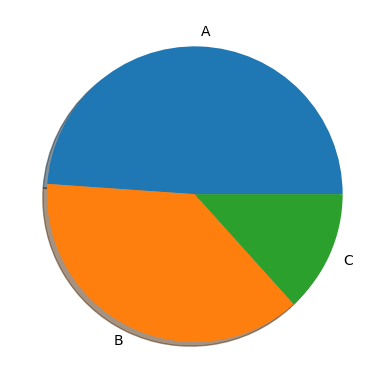

A    22
B    17
C     6
Name: Type, dtype: int64


In [4]:
# Plot pie chart of store types and display their counts
plt.pie(x =stores_df.Type.value_counts(), shadow = True, labels = stores_df.Type.unique())
plt.show()
print(stores_df.Type.value_counts())


In [5]:
# Display the contents of the feature dataset
feature_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False



**Store:** The store number

**Date:** Specifying the Week (Friday of every Week)

**Temperature:** Average temperature in the region (in ℉)

**FuelPrice:** Cost of fuel in the region

**MarkDown1-5:** Anonymized data related to promotional markdowns that Walmart is running.

**CPI:** Consumer price index

**Unemployment:** Unemployment rate

**IsHoliday:** Whether the week is a special holiday week


In [6]:

# Check missing values in feature dataset and display sales dataset 1
feature_df.isna().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [7]:
sales_df1

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False
...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False
421566,45,98,05/10/2012,628.10,False
421567,45,98,12/10/2012,1061.02,False
421568,45,98,19/10/2012,760.01,False


In [8]:
sales_df2

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False
...,...,...,...,...
115059,45,98,2013-06-28,False
115060,45,98,2013-07-05,False
115061,45,98,2013-07-12,False
115062,45,98,2013-07-19,False



**Store:** The store number

**Dept:** Department of the Store

**Date:** Specifying the Week (Friday of every Week)

**Weekly_Sales:** Total Sales Per Week

**IsHoliday:** Whether the week is a special holiday week

In [9]:
# Display unique department IDs from sales dataset 1
sales_df1.Dept.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65], dtype=int64)

In [10]:
# Count the number of unique department IDs in sales dataset 1
sales_df1.Dept.nunique()

81

In [11]:
# Create pivot table showing average weekly sales per store and department
store_dept_table = pd.pivot_table(sales_df1, index='Store', columns='Dept',
                                  values='Weekly_Sales', aggfunc=np.mean)
display(store_dept_table)

Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Store,,,,,,,,,,,,,,,,,,,,,
1,22513.322937,46102.090420,13150.478042,36964.154476,24257.941119,4801.780140,24566.487413,35718.257622,28062.052238,31033.386364,...,82427.547832,64238.943427,135458.969510,71699.182378,63180.568182,120772.062168,33251.831639,35207.348811,11827.770769,306.091081
2,30777.980769,65912.922517,17476.563357,45607.666573,30555.315315,6808.382517,40477.837063,58707.369441,34375.864476,38845.854476,...,97611.537133,80610.380350,164840.230979,70581.977063,70018.672517,143588.751888,34319.063846,40697.204056,14035.400839,475.896905
3,7328.621049,16841.775664,5509.300769,8434.186503,11695.366573,2012.411818,10044.341608,8310.254196,9062.007692,10871.944126,...,1540.049161,318.685594,7568.280210,NaN,656.294444,15745.528252,3934.540000,343.437357,30.570833,NaN
4,36979.940070,93639.315385,19012.491678,56603.400140,45668.406783,8241.777692,50728.151399,62949.723776,34437.170979,37269.667413,...,89248.965524,66535.407203,159365.107902,67815.163007,68159.106573,147236.473706,38346.573077,39339.238951,15009.249371,623.182381
5,9774.553077,12317.953287,4101.085175,9860.806783,6699.202238,1191.057622,6124.484336,13735.709441,7919.805944,9783.395385,...,3059.520000,1457.221678,7759.205594,NaN,411.431486,19340.693986,5985.671119,667.070315,29.976087,NaN
6,23867.553776,50269.437273,16806.638811,34187.366503,34465.307622,7225.566643,34526.870420,47577.719790,48271.060140,47436.477902,...,53715.366084,45270.405175,99024.796503,41359.651189,41701.693497,89208.786294,30450.542238,20637.667063,9728.100629,388.636750
7,9542.801259,22603.690769,8633.536923,14950.518601,13860.350490,6329.928811,10925.757063,13970.619371,29722.736084,21136.560280,...,13858.405874,10263.880000,26530.890559,1328.178252,699.332522,34208.097273,1123.383217,4374.927902,260.886596,15.000000
8,14789.827343,35729.821748,10683.305105,21089.309301,19838.849231,3395.425455,20268.743776,26438.524336,11792.661678,20666.433776,...,39333.566154,31530.560909,60465.630000,27515.635315,25442.578042,62951.463706,16.986667,16978.366503,6880.466434,298.153714
9,11846.558252,24969.477413,7497.356783,17165.947762,19282.746014,2806.416364,13826.694336,21424.470699,13196.569720,12810.480350,...,2981.249510,869.273287,14123.063147,21.240000,599.112568,29575.050769,3596.107762,372.655556,27.930000,NaN


## 🔍 Exploratory Data Analysis (EDA) on Raw Data

EDA on raw data was performed to understand the overall structure, data distributions, and missing value patterns before any transformation or imputation.

Key steps included:
- Displaying `.head()` and `.info()` to inspect structure
- Checking `.isna().sum()` to identify missing values in MarkDown1–5, CPI, and Unemployment
- Plotting univariate distributions (histograms) to observe skewness and outliers
- Generating correlation heatmaps on raw features to detect early relationships
- Boxplots and scatter plots were used to examine outliers and feature spread

This initial EDA helped guide the feature engineering and imputation strategies used later in the workflow.


In [12]:
# --- MISSING VALUES CHECK ---

sales_df = pd.concat([sales_df1, sales_df2], ignore_index=True)
print("🧩 Missing Values:")
print("Stores:")
print(stores_df.isna().sum(), '\n')

🧩 Missing Values:
Stores:
Store    0
Type     0
Size     0
dtype: int64 



In [13]:

print("Features:")
print(feature_df.isna().sum(), '\n')


Features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64 



In [14]:
print("Sales:")
print(sales_df.isna().sum(), '\n')

Sales:
Store                0
Dept                 0
Date                 0
Weekly_Sales    115064
IsHoliday            0
dtype: int64 



In [15]:
# --- BASIC STATS ---
print("\n📊 Summary Stats:")
print("Feature DF:\n", feature_df.describe(), '\n')



📊 Summary Stats:
Feature DF:
              Store  Temperature   Fuel_Price      MarkDown1      MarkDown2  \
count  8190.000000  8190.000000  8190.000000    4032.000000    2921.000000   
mean     23.000000    59.356198     3.405992    7032.371786    3384.176594   
std      12.987966    18.678607     0.431337    9262.747448    8793.583016   
min       1.000000    -7.290000     2.472000   -2781.450000    -265.760000   
25%      12.000000    45.902500     3.041000    1577.532500      68.880000   
50%      23.000000    60.710000     3.513000    4743.580000     364.570000   
75%      34.000000    73.880000     3.743000    8923.310000    2153.350000   
max      45.000000   101.950000     4.468000  103184.980000  104519.540000   

           MarkDown3     MarkDown4      MarkDown5          CPI  Unemployment  
count    3613.000000   3464.000000    4050.000000  7605.000000   7605.000000  
mean     1760.100180   3292.935886    4132.216422   172.460809      7.826821  
std     11276.462208   6792.3

In [16]:

print("Sales DF:\n", sales_df.describe(), '\n')

Sales DF:
                Store           Dept   Weekly_Sales
count  536634.000000  536634.000000  421570.000000
mean       22.208621      44.277301   15981.258123
std        12.790580      30.527358   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000 



## Univariate Analysis

📊 Distribution Plots (Histograms):


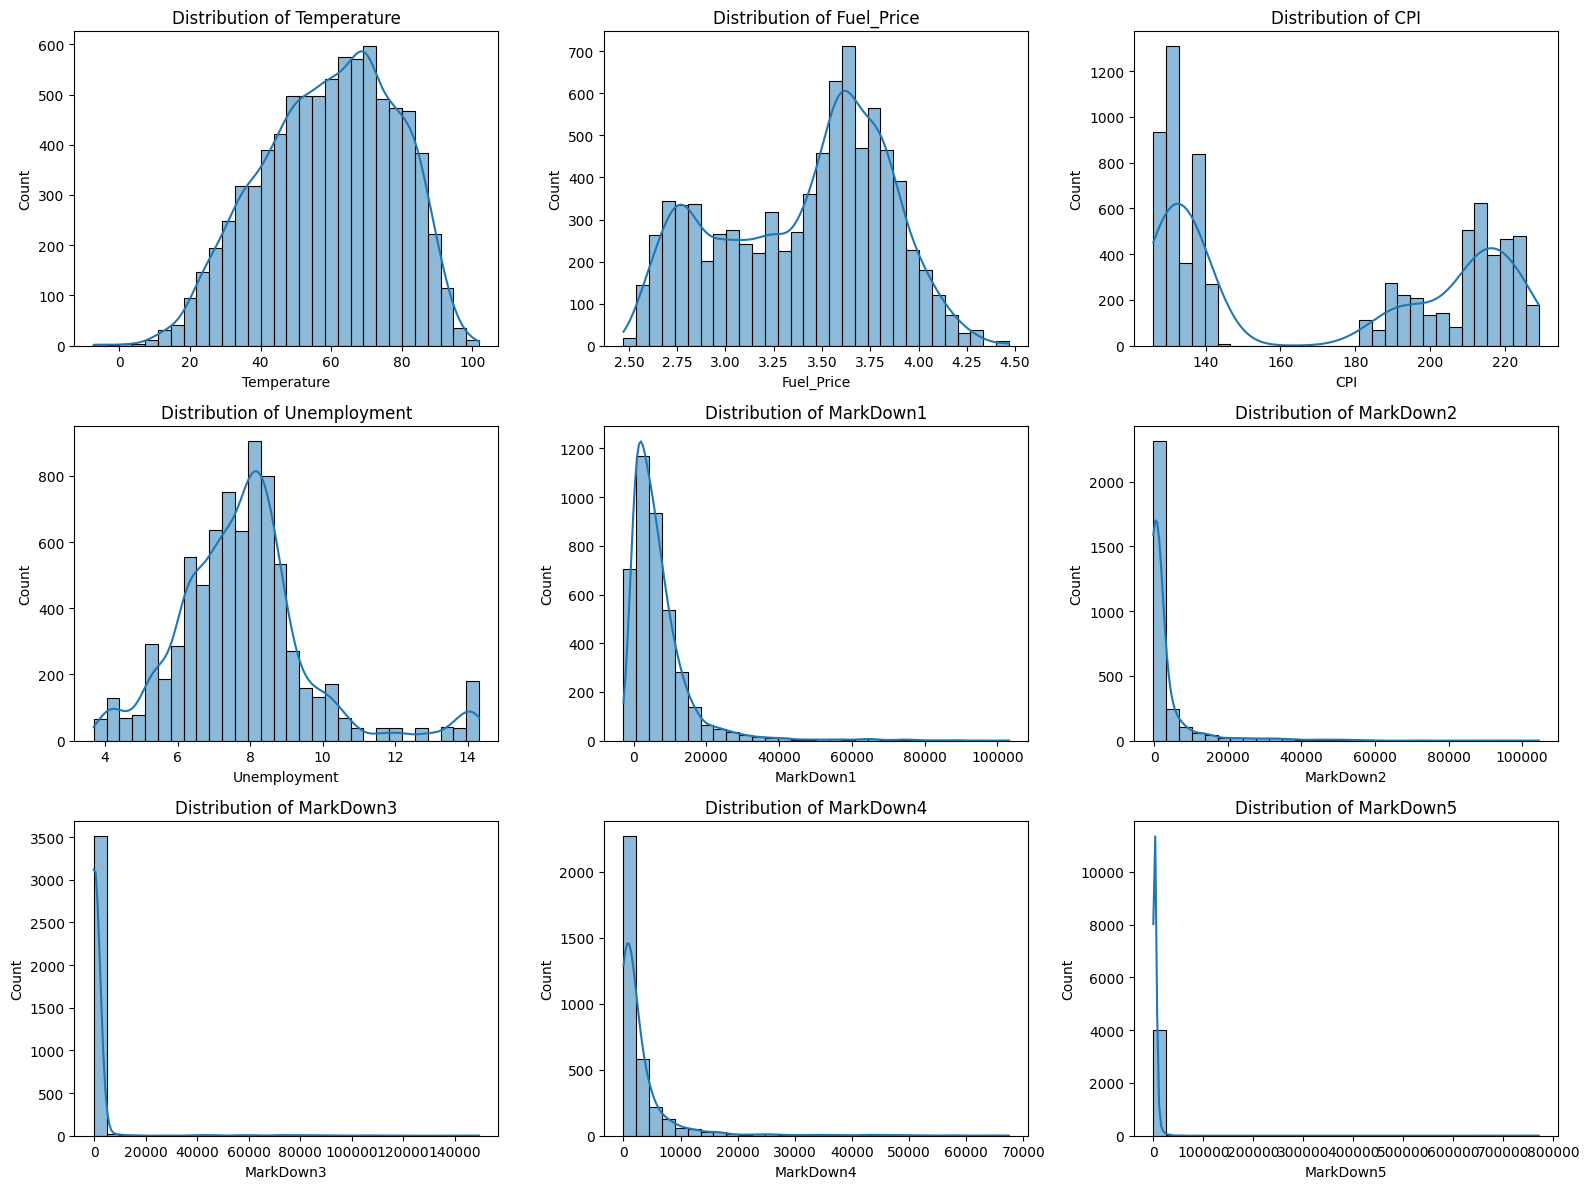

In [17]:
# Sample numerical columns from feature_df
num_cols_feat = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

print("📊 Distribution Plots (Histograms):")
ncols = 3
nrows = -(-len(num_cols_feat) // ncols)  # Ceiling division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
for i, col in enumerate(num_cols_feat):
    ax = axes.flat[i]
    sns.histplot(feature_df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes.flat[j])
plt.tight_layout()
plt.show()

📦 Outlier Detection (Boxplots):


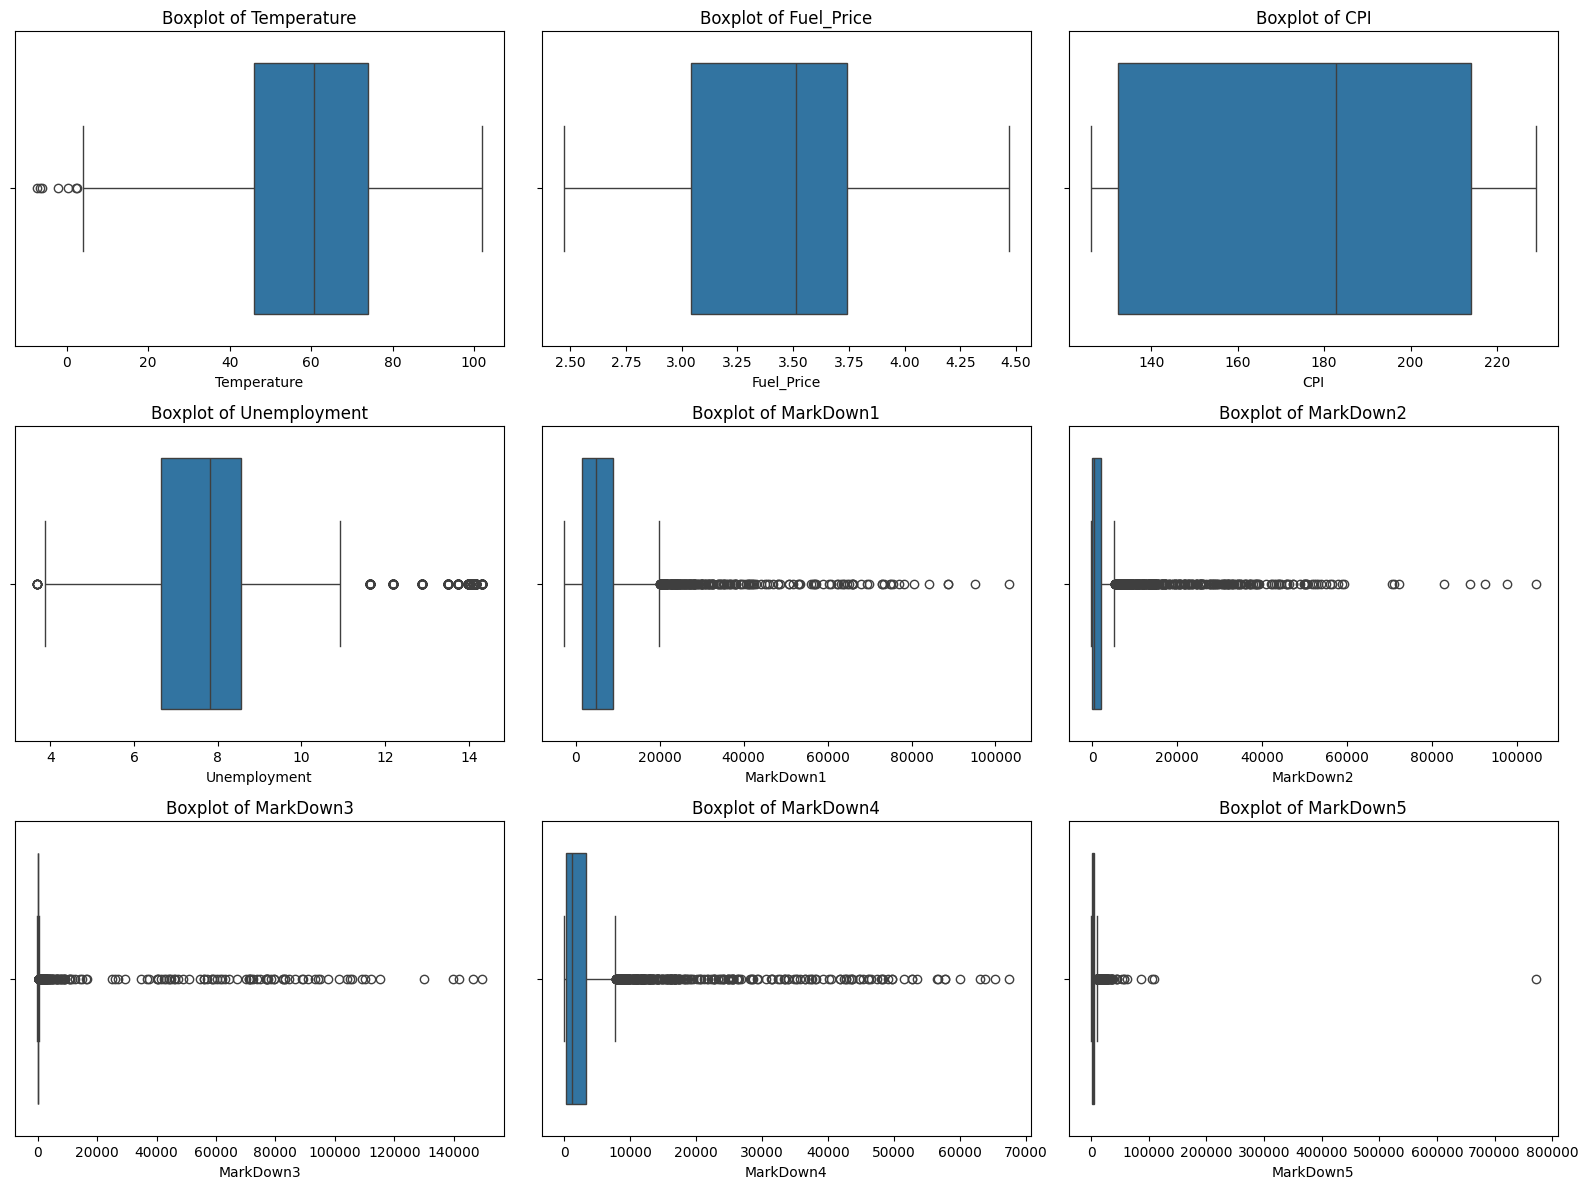

In [18]:
# --- BOXPLOTS ---
print("📦 Outlier Detection (Boxplots):")
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
for i, col in enumerate(num_cols_feat):
    ax = axes.flat[i]
    sns.boxplot(x=feature_df[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes.flat[j])
plt.tight_layout()
plt.show()

##  Bivariate Analysis

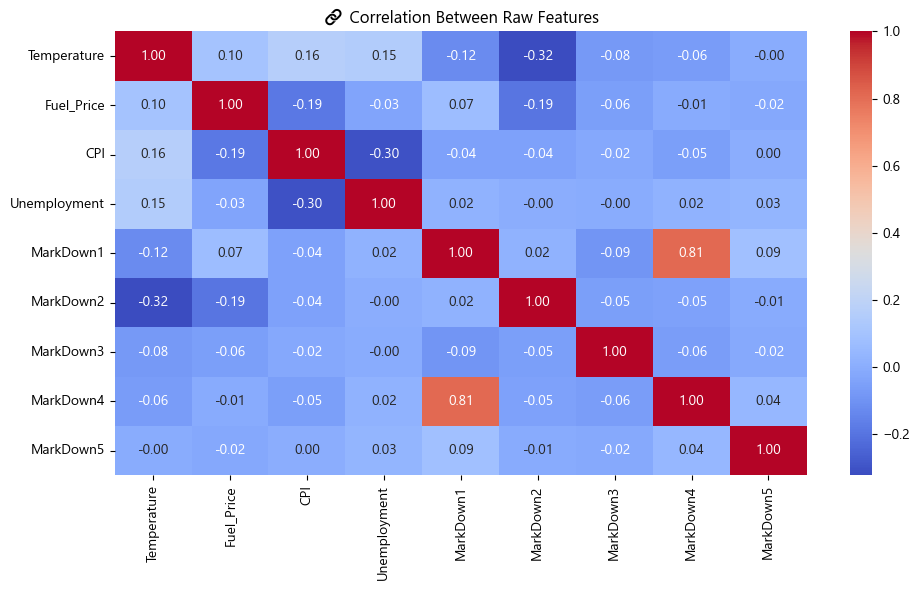

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Segoe UI Emoji'  # Windows users (try "Arial Unicode MS" if needed)
# plt.rcParams['font.family'] = 'Apple Color Emoji'  # macOS users
# plt.rcParams['font.family'] = 'Noto Color Emoji'  # Linux users

plt.figure(figsize=(10, 6))
sns.heatmap(feature_df[num_cols_feat].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("🔗 Correlation Between Raw Features")
plt.tight_layout()
plt.show()


## Milestone 2 - Version 1 (Week 4)
## Data Preprocessing
- Approve preprocessing techniques.
- Validate data treatments.



## 🧹 Data Preprocessing Summary
1. Data Loading
Four datasets were loaded using pandas.read_csv():

* sales_data_set.csv 
* Features_data_set.csv 
* stores_data_set.csv 

2. Initial Data Inspection
Inspected structure using .head(), .value_counts(), and .nunique() to understand store types and department diversity.

3. Missing Value Analysis
Used .isna().sum() to identify missing values in:
MarkDown1–5
CPI and Unemployment

4. Dataset Merging
Merged feature_df and stores_df on the Store column using an inner join to create feature_store_df.

5. Datetime Conversion
Converted the Date column to datetime format using pd.to_datetime() for temporal feature extraction.

6. MarkDown Null Segmentation & Imputation
Split data into two parts: before and after 2011-11-04 (when MarkDowns started).
Imputed missing values in MarkDown1–5 with 0 for rows after that date.

7. CPI & Unemployment Null Handling
Identified that CPI and Unemployment had missing values after 2013-05-03.
Segregated null and non-null subsets for later imputation or analysis.

8. Date Component Extraction (in Subsets)
In CPI/Unemployment subsets only, extracted Day, Month, and Year from the Date column and temporarily dropped Date for further feature handling.


### Handling Missing Values

In [159]:
# Display the feature dataset
feature_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [160]:
# Show the number of missing values in each column of the feature dataset
feature_df.isna().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [161]:
# Merge store and feature datasets on 'Store' column using inner join
feature_store_df= pd.merge(stores_df, feature_df, on = 'Store', how = 'inner' )
feature_store_df

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,A,151315,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,A,151315,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,A,151315,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,A,151315,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,A,151315,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,B,118221,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,B,118221,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,B,118221,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,B,118221,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [162]:
# Convert 'Date' to datetime format and extract ISO week number
feature_store_df['Date'] = pd.to_datetime(feature_store_df['Date'], format = '%d/%m/%Y')
feature_store_df['Week_Number'] = feature_store_df['Date'].dt.isocalendar().week

In [163]:
feature_store_df['Date'].min(), feature_store_df['Date'].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2013-07-26 00:00:00'))

### Is Holiday

In [164]:
# Get unique holiday dates from the feature-store dataset
feature_store_df[feature_store_df.IsHoliday==True]['Date'].unique()

array(['2010-02-12T00:00:00.000000000', '2010-09-10T00:00:00.000000000',
       '2010-11-26T00:00:00.000000000', '2010-12-31T00:00:00.000000000',
       '2011-02-11T00:00:00.000000000', '2011-09-09T00:00:00.000000000',
       '2011-11-25T00:00:00.000000000', '2011-12-30T00:00:00.000000000',
       '2012-02-10T00:00:00.000000000', '2012-09-07T00:00:00.000000000',
       '2012-11-23T00:00:00.000000000', '2012-12-28T00:00:00.000000000',
       '2013-02-08T00:00:00.000000000'], dtype='datetime64[ns]')

In [165]:
# Count how many holidays occurred in each week number
feature_store_df[feature_store_df.IsHoliday==True]['Week_Number'].value_counts()

6     180
36    135
47    135
52    135
Name: Week_Number, dtype: Int64

All holidays are not in the data. There are 4 holiday values such as;

1. **Super Bowl:**
   - Super Bowl usually takes place in the first week of February. It is often on the first Sunday of February, so it falls in Week 5 or 6 of the year.

2. **Labor Day:**
   - Labor Day is celebrated on the first Monday of September. Therefore, it typically falls in Week 36 or 37 of the year.

3. **Thanksgiving:**
   - Thanksgiving is observed on the fourth Thursday of November. It generally falls in Week 47 or 48 of the year.

4. **Christmas:**
   - Christmas is on December 25th every year. It falls in Week 51 or 52 of the year, depending on the calendar.


In [166]:
# Label holidays by week number; others marked as 'No Holiday'
feature_store_df['IsHoliday'] = np.where((feature_store_df['IsHoliday']==True) & (feature_store_df['Week_Number'] == 6), 'Super Bowl',
                                    np.where((feature_store_df['IsHoliday']==True) & (feature_store_df['Week_Number'] == 36), 'Labor Day',
                                    np.where((feature_store_df['IsHoliday']==True) & (feature_store_df['Week_Number'] == 47), 'Thanksgiving', 
                                    np.where((feature_store_df['IsHoliday']==True) & (feature_store_df['Week_Number'] == 52), 'Christmas',  'No Holiday'))))

In [167]:
# Count occurrences of each holiday label
feature_store_df['IsHoliday'].value_counts()

No Holiday      7605
Super Bowl       180
Labor Day        135
Thanksgiving     135
Christmas        135
Name: IsHoliday, dtype: int64

In [168]:
# Display the merged and updated feature-store dataset
feature_store_df

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,No Holiday,5
1,1,A,151315,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,Super Bowl,6
2,1,A,151315,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,No Holiday,7
3,1,A,151315,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,No Holiday,8
4,1,A,151315,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,No Holiday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,B,118221,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,No Holiday,26
8186,45,B,118221,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,No Holiday,27
8187,45,B,118221,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,No Holiday,28
8188,45,B,118221,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,No Holiday,29


## 🔖 MarkDown1–5: Feature Significance

These columns represent different types of **promotional discounts** offered by the store during a given week.

- **Impact:** Promotions strongly influence `Weekly_Sales`, often boosting them during holiday periods or sales events.

The model uses MarkDown1–5 to learn how promotional discounts influence Weekly_Sales, identifying patterns like higher markdowns leading to increased sales.

> ✅ MarkDown features enhance the model's ability to predict sales spikes linked to promotions.


In [169]:
# Filter rows where all MarkDown columns have missing values
markdown_null =feature_store_df[(feature_store_df.MarkDown1.isna()==True) & (feature_store_df.MarkDown2.isna()==True) & (feature_store_df.MarkDown3.isna()==True) & (feature_store_df.MarkDown4.isna()==True) & (feature_store_df.MarkDown5.isna()==True)]
markdown_null

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,No Holiday,5
1,1,A,151315,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,Super Bowl,6
2,1,A,151315,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,No Holiday,7
3,1,A,151315,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,No Holiday,8
4,1,A,151315,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,No Holiday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,45,B,118221,2011-10-07,55.82,3.583,NaN,NaN,NaN,NaN,NaN,187.483796,8.523,No Holiday,40
8096,45,B,118221,2011-10-14,63.82,3.541,NaN,NaN,NaN,NaN,NaN,187.691748,8.523,No Holiday,41
8097,45,B,118221,2011-10-21,59.60,3.570,NaN,NaN,NaN,NaN,NaN,187.784620,8.523,No Holiday,42
8098,45,B,118221,2011-10-28,51.78,3.569,NaN,NaN,NaN,NaN,NaN,187.877491,8.523,No Holiday,43


In [170]:
# Print shape, null counts for MarkDown columns, and date range of missing data
print('Shape: ', markdown_null.shape)
print('Null values: ', {f'MarkDown{i}':markdown_null[f'MarkDown{i}'].isna().sum() for i in range(1,6)} )
print('From date: ', markdown_null.Date.min())
print('To date: ', markdown_null.Date.max())

Shape:  (4140, 15)
Null values:  {'MarkDown1': 4140, 'MarkDown2': 4140, 'MarkDown3': 4140, 'MarkDown4': 4140, 'MarkDown5': 4140}
From date:  2010-02-05 00:00:00
To date:  2011-11-04 00:00:00


Markdown data is not available from Feburary 2010 to 4th November 2011.

Markdown data is only available after **November 2011**, and is not available for all stores all the time.

In [171]:
# Split data based on date into null and non-null MarkDown groups and reset their indices
markdown_null = feature_store_df[feature_store_df.Date <= '2011-11-04']
markdown_notnull = feature_store_df[feature_store_df.Date > '2011-11-04']
markdown_null.reset_index(drop=True,  inplace = True)
markdown_notnull.reset_index(drop=True,  inplace = True)
markdown_null

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,No Holiday,5
1,1,A,151315,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,Super Bowl,6
2,1,A,151315,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,No Holiday,7
3,1,A,151315,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,No Holiday,8
4,1,A,151315,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,No Holiday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,45,B,118221,2011-10-07,55.82,3.583,NaN,NaN,NaN,NaN,NaN,187.483796,8.523,No Holiday,40
4136,45,B,118221,2011-10-14,63.82,3.541,NaN,NaN,NaN,NaN,NaN,187.691748,8.523,No Holiday,41
4137,45,B,118221,2011-10-21,59.60,3.570,NaN,NaN,NaN,NaN,NaN,187.784620,8.523,No Holiday,42
4138,45,B,118221,2011-10-28,51.78,3.569,NaN,NaN,NaN,NaN,NaN,187.877491,8.523,No Holiday,43


In [172]:
# Display data with non-null MarkDown values (after 2011-11-04)
markdown_notnull

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2011-11-11,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,No Holiday,45
1,1,A,151315,2011-11-18,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,No Holiday,46
2,1,A,151315,2011-11-25,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,Thanksgiving,47
3,1,A,151315,2011-12-02,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,No Holiday,48
4,1,A,151315,2011-12-09,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,No Holiday,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,45,B,118221,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,No Holiday,26
4046,45,B,118221,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,No Holiday,27
4047,45,B,118221,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,No Holiday,28
4048,45,B,118221,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,No Holiday,29


In [173]:
# Print shape, MarkDown null counts, and date range for non-null MarkDown data
print('Shape: ', markdown_notnull.shape)
print('Null values: ', {f'MarkDown{i}':markdown_notnull[f'MarkDown{i}'].isna().sum() for i in range(1,6)} )
print('From date: ', markdown_notnull.Date.min())
print('To date: ', markdown_notnull.Date.max())

Shape:  (4050, 15)
Null values:  {'MarkDown1': 18, 'MarkDown2': 1129, 'MarkDown3': 437, 'MarkDown4': 586, 'MarkDown5': 0}
From date:  2011-11-11 00:00:00
To date:  2013-07-26 00:00:00


In [174]:
# Print total and date-wise null counts for each MarkDown column
print('Null value counts till 04-11-2011')
for i in range(1,6):
    col = f'MarkDown{i}'
    print(f'Column Name: {col} --Total Null values-->{feature_store_df[col].isna().sum()} ---Till Nov 2011 Null Values--> {markdown_null[col].isna().sum()} --Remaining / After 04-11-2011 Null values--> {feature_store_df[col].isna().sum() -markdown_null[col].isna().sum()}')


Null value counts till 04-11-2011
Column Name: MarkDown1 --Total Null values-->4158 ---Till Nov 2011 Null Values--> 4140 --Remaining / After 04-11-2011 Null values--> 18
Column Name: MarkDown2 --Total Null values-->5269 ---Till Nov 2011 Null Values--> 4140 --Remaining / After 04-11-2011 Null values--> 1129
Column Name: MarkDown3 --Total Null values-->4577 ---Till Nov 2011 Null Values--> 4140 --Remaining / After 04-11-2011 Null values--> 437
Column Name: MarkDown4 --Total Null values-->4726 ---Till Nov 2011 Null Values--> 4140 --Remaining / After 04-11-2011 Null values--> 586
Column Name: MarkDown5 --Total Null values-->4140 ---Till Nov 2011 Null Values--> 4140 --Remaining / After 04-11-2011 Null values--> 0


In [175]:
# Print null value count for each MarkDown column after 2011-11-04
for i in range(1,6):
    col = f'MarkDown{i}'
    print(f'Column Name: {col} ---Null Values--> {markdown_notnull[col].isna().sum()}')

Column Name: MarkDown1 ---Null Values--> 18
Column Name: MarkDown2 ---Null Values--> 1129
Column Name: MarkDown3 ---Null Values--> 437
Column Name: MarkDown4 ---Null Values--> 586
Column Name: MarkDown5 ---Null Values--> 0


In [176]:
# Filter rows after 2011-11-04 where all MarkDown columns are still missing
markdown_notnull[(markdown_notnull.MarkDown1.isna()==True) & (markdown_notnull.MarkDown2.isna()==True) & (markdown_notnull.MarkDown3.isna()==True) & 
                 (markdown_notnull.MarkDown4.isna()==True) & (markdown_notnull.MarkDown5.isna()==True)]


,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number


In [177]:
# Fill missing values in MarkDown columns with 0 for data after 2011-11-04
for i in range(1,6):
    column = f'MarkDown{i}'
    markdown_notnull[column].fillna(0, inplace = True)

C:\Users\praka\AppData\Local\Temp\ipykernel_19648\1708062406.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  markdown_notnull[column].fillna(0, inplace = True)


In [178]:
# Verify that there are no null values remaining in MarkDown columns after filling
for i in range(1,6):
    col = f'MarkDown{i}'
    print(f'Column Name: {col} ---Null Values--> {markdown_notnull[col].isna().sum()}')

Column Name: MarkDown1 ---Null Values--> 0
Column Name: MarkDown2 ---Null Values--> 0
Column Name: MarkDown3 ---Null Values--> 0
Column Name: MarkDown4 ---Null Values--> 0
Column Name: MarkDown5 ---Null Values--> 0


In [179]:
# Display total missing values in each column of the non-null MarkDown dataset
markdown_notnull.isna().sum()

Store             0
Type              0
Size              0
Date              0
Temperature       0
Fuel_Price        0
MarkDown1         0
MarkDown2         0
MarkDown3         0
MarkDown4         0
MarkDown5         0
CPI             585
Unemployment    585
IsHoliday         0
Week_Number       0
dtype: int64

### CPI & Unemployment

In [180]:
# Display the cleaned dataset with no missing values in MarkDown columns
markdown_notnull

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2011-11-11,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,No Holiday,45
1,1,A,151315,2011-11-18,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,No Holiday,46
2,1,A,151315,2011-11-25,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,Thanksgiving,47
3,1,A,151315,2011-12-02,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,No Holiday,48
4,1,A,151315,2011-12-09,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,No Holiday,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,45,B,118221,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,No Holiday,26
4046,45,B,118221,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,No Holiday,27
4047,45,B,118221,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,No Holiday,28
4048,45,B,118221,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,No Holiday,29


In [181]:
# Filter rows where both CPI and Unemployment values are missing
cpi_unemp_null = markdown_notnull[(markdown_notnull.CPI.isna()==True) & (markdown_notnull.Unemployment.isna()==True) ]
cpi_unemp_null

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
77,1,A,151315,2013-05-03,66.66,3.386,2298.63,2.00,129.90,55.46,1301.04,NaN,NaN,No Holiday,18
78,1,A,151315,2013-05-10,63.90,3.392,4624.61,83.88,42.38,1618.31,8144.90,NaN,NaN,No Holiday,19
79,1,A,151315,2013-05-17,69.53,3.454,16170.50,92.00,8.32,4127.24,6206.97,NaN,NaN,No Holiday,20
80,1,A,151315,2013-05-24,77.19,3.494,7959.89,178.00,1621.47,3152.57,2938.70,NaN,NaN,No Holiday,21
81,1,A,151315,2013-05-31,78.02,3.466,2369.77,142.45,475.35,45.55,2056.84,NaN,NaN,No Holiday,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,45,B,118221,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,No Holiday,26
4046,45,B,118221,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,No Holiday,27
4047,45,B,118221,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,No Holiday,28
4048,45,B,118221,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,No Holiday,29


In [182]:
# Print shape, null counts for CPI and Unemployment, and their date range
print('Shape: ', cpi_unemp_null.shape)
print('Null values: ', {column:cpi_unemp_null[column].isna().sum() for column in ['CPI', 'Unemployment']} )
print('From date: ', cpi_unemp_null.Date.min())
print('To date: ', cpi_unemp_null.Date.max())

Shape:  (585, 15)
Null values:  {'CPI': 585, 'Unemployment': 585}
From date:  2013-05-03 00:00:00
To date:  2013-07-26 00:00:00


In [183]:
# Split data based on date into CPI/Unemployment null and non-null groups, then reset indices
cpi_unemp_null = markdown_notnull[markdown_notnull.Date >= '2013-05-03']
cpi_unemp_notnull = markdown_notnull[markdown_notnull.Date < '2013-05-03']
cpi_unemp_null.reset_index(drop=True,  inplace = True)
cpi_unemp_notnull.reset_index(drop=True,  inplace = True)
cpi_unemp_null

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2013-05-03,66.66,3.386,2298.63,2.00,129.90,55.46,1301.04,NaN,NaN,No Holiday,18
1,1,A,151315,2013-05-10,63.90,3.392,4624.61,83.88,42.38,1618.31,8144.90,NaN,NaN,No Holiday,19
2,1,A,151315,2013-05-17,69.53,3.454,16170.50,92.00,8.32,4127.24,6206.97,NaN,NaN,No Holiday,20
3,1,A,151315,2013-05-24,77.19,3.494,7959.89,178.00,1621.47,3152.57,2938.70,NaN,NaN,No Holiday,21
4,1,A,151315,2013-05-31,78.02,3.466,2369.77,142.45,475.35,45.55,2056.84,NaN,NaN,No Holiday,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,45,B,118221,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,No Holiday,26
581,45,B,118221,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,No Holiday,27
582,45,B,118221,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,No Holiday,28
583,45,B,118221,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,No Holiday,29


In [184]:
cpi_unemp_notnull

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2011-11-11,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,No Holiday,45
1,1,A,151315,2011-11-18,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,No Holiday,46
2,1,A,151315,2011-11-25,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,Thanksgiving,47
3,1,A,151315,2011-12-02,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,No Holiday,48
4,1,A,151315,2011-12-09,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,No Holiday,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3460,45,B,118221,2013-03-29,40.68,3.784,5444.00,0.00,350.84,53.90,1722.11,193.442790,8.625,No Holiday,13
3461,45,B,118221,2013-04-05,43.94,3.763,16427.83,5341.41,182.59,1523.83,1743.09,193.516047,8.335,No Holiday,14
3462,45,B,118221,2013-04-12,57.39,3.724,8760.15,1713.11,21.08,1302.31,1380.74,193.589304,8.335,No Holiday,15
3463,45,B,118221,2013-04-19,56.27,3.676,1399.81,39.89,44.38,60.83,1445.05,193.589304,8.335,No Holiday,16


In [185]:
# Print shape, CPI and Unemployment null counts, and date range for CPI/Unemployment null data
print('Shape: ', cpi_unemp_null.shape)
print('Null values: ', {column:cpi_unemp_null[column].isna().sum() for column in ['CPI', 'Unemployment']} )
print('From date: ', cpi_unemp_null.Date.min())
print('To date: ', cpi_unemp_null.Date.max())

Shape:  (585, 15)
Null values:  {'CPI': 585, 'Unemployment': 585}
From date:  2013-05-03 00:00:00
To date:  2013-07-26 00:00:00


In [186]:
print('Shape: ', cpi_unemp_notnull.shape)
print('Null values: ', {column:cpi_unemp_notnull[column].isna().sum() for column in ['CPI', 'Unemployment']} )
print('From date: ', cpi_unemp_notnull.Date.min())
print('To date: ', cpi_unemp_notnull.Date.max())

Shape:  (3465, 15)
Null values:  {'CPI': 0, 'Unemployment': 0}
From date:  2011-11-11 00:00:00
To date:  2013-04-26 00:00:00


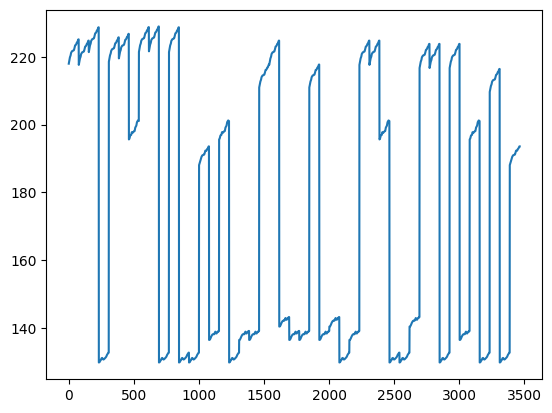

In [187]:
# Plot CPI values over time for non-null CPI data
plt.plot(cpi_unemp_notnull['CPI'])
plt.show()

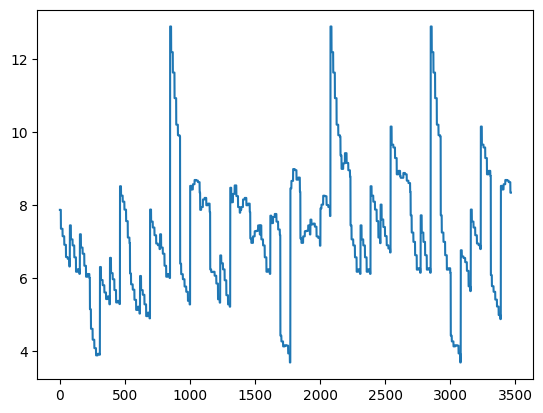

In [188]:

# Plot Unemployment values over time for non-null data
plt.plot(cpi_unemp_notnull['Unemployment'])
plt.show()

In [ ]:

# Extract day, month, year from Date and drop original Date column
cpi_unemp_notnull_df = cpi_unemp_notnull.copy()
cpi_unemp_notnull_df['Day'] = cpi_unemp_notnull_df['Date'].dt.day
cpi_unemp_notnull_df['Month'] = cpi_unemp_notnull_df['Date'].dt.month
cpi_unemp_notnull_df['Year'] = cpi_unemp_notnull_df['Date'].dt.year

cpi_unemp_notnull_df.drop('Date', axis =1, inplace = True)
cpi_unemp_notnull_df.head()

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,A,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,No Holiday,45,11,11,2011
1,1,A,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,No Holiday,46,18,11,2011
2,1,A,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,Thanksgiving,47,25,11,2011
3,1,A,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,No Holiday,48,2,12,2011
4,1,A,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,No Holiday,49,9,12,2011


In [190]:
# Extract day, month, year from Date for CPI/Unemployment null data and drop Date column
cpi_unemp_null_df = cpi_unemp_null.copy()
cpi_unemp_null_df['Day'] = cpi_unemp_null_df['Date'].dt.day
cpi_unemp_null_df['Month'] = cpi_unemp_null_df['Date'].dt.month
cpi_unemp_null_df['Year'] = cpi_unemp_null_df['Date'].dt.year

cpi_unemp_null_df.drop('Date', axis =1, inplace = True)
cpi_unemp_null_df.head()

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,A,151315,66.66,3.386,2298.63,2.00,129.90,55.46,1301.04,NaN,NaN,No Holiday,18,3,5,2013
1,1,A,151315,63.90,3.392,4624.61,83.88,42.38,1618.31,8144.90,NaN,NaN,No Holiday,19,10,5,2013
2,1,A,151315,69.53,3.454,16170.50,92.00,8.32,4127.24,6206.97,NaN,NaN,No Holiday,20,17,5,2013
3,1,A,151315,77.19,3.494,7959.89,178.00,1621.47,3152.57,2938.70,NaN,NaN,No Holiday,21,24,5,2013
4,1,A,151315,78.02,3.466,2369.77,142.45,475.35,45.55,2056.84,NaN,NaN,No Holiday,22,31,5,2013


In [191]:

# Convert categorical 'IsHoliday' and 'Type' columns to numerical values
holiday = {'No Holiday':0, 
           'Super Bowl':1,
           'Labor Day':2,
           'Thanksgiving':3,
           'Christmas':4,}
Type = {"A":1, "B":2, "C":3}

cpi_unemp_notnull_df['IsHoliday'] = cpi_unemp_notnull_df["IsHoliday"].map(holiday)
cpi_unemp_notnull_df['Type'] = cpi_unemp_notnull_df["Type"].map(Type)

cpi_unemp_null_df['IsHoliday'] = cpi_unemp_null_df["IsHoliday"].map(holiday)
cpi_unemp_null_df['Type'] = cpi_unemp_null_df["Type"].map(Type)

In [192]:
cpi_unemp_notnull_df.dtypes

Store             int64
Type              int64
Size              int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday         int64
Week_Number      UInt32
Day               int64
Month             int64
Year              int64
dtype: object


## 🧠 Feature Engineering Summary 

1. **Holiday Mapping**  
   - Converted boolean `IsHoliday` to actual holiday names.  
   ➤ *Improves interpretability and captures specific holiday effects on sales.*

2. **Date Feature Extraction**  
   - Extracted `Day`, `Month`, `Year`, and `Week_Number` from `Date`.  
   ➤ *Captures seasonality, trends, and weekly patterns.*

3. **MarkDown Handling**  
   - Separated rows with missing MarkDowns (before 2011-11-04).  
   - Imputed using `RandomForestRegressor`.  
   ➤ *Preserves valuable promotional features without dropping data.*

4. **CPI & Unemployment Imputation**  
   - Identified missing values after 2013 and predicted them using `HistGradientBoostingRegressor`.  
   ➤ *Ensures complete economic context for each record.*

5. **Categorical Encoding**  
   - Encoded `Type` and `IsHoliday` to numerical values.  
   ➤ *Makes categorical data usable for machine learning models.*

6. **New Feature: `Is_MarkUp`**  
   - Created binary flag for negative markdowns (price increases).  
   ➤ *Flags unusual pricing behavior that may impact sales.*

7. **Final Feature Selection**  
   - Selected cleaned and engineered features for modeling.  
   ➤ *Prepares a high-quality input set for accurate model training.*




## 🏗️ Model Preparation Summary
### ✅ Key Steps:
- Encoded categorical columns (`Type`, `IsHoliday`)
- Extracted date-based features (`Day`, `Month`, `Year`, `Week_Number`)
- Imputed missing values (CPI, Unemployment, MarkDowns) using ML models
- Created new feature: `Is_MarkUp`
- Finalized feature set and exported as `Combined_dataset.csv`


In [193]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  r2_score

In [194]:
class regression:

    def __init__(self, x, y):
        # List of regression models to be evaluated
        self.models =[('AdaBoostRegressor', AdaBoostRegressor()),
                     ('RandomForestRegressor', RandomForestRegressor()),
                     ('ExtraTreesRegressor', ExtraTreesRegressor()),
                     ('GradientBoostingRegressor', GradientBoostingRegressor()),
                     ('HistGradientBoostingRegressor', HistGradientBoostingRegressor()),
                     ('DecisionTreeRegressor', DecisionTreeRegressor()),
                     ('XGBRegressor', XGBRegressor()),
                     ('LinearRegression', LinearRegression()),
                     ('KNeighborsRegressor', KNeighborsRegressor()),
                     ('MLPRegressor', MLPRegressor()),
                     ]
        # Split the data into training and testing sets
        self.x_train, self.x_test, self.y_train,self.y_test = train_test_split(x,y,test_size=0.2, random_state = 42)
    
    def all_model(self):
        # Train and evaluate each model
        print(self.x_train.shape, self.x_test.shape, self.y_train.shape, self.y_test.shape)
        result = []
        for model_name, model in self.models:
            model.fit(self.x_train, self.y_train)
            y_test_pred = model.predict(self.x_test)
            y_train_pred = model.predict(self.x_train)
            
            data ={'Model_Name': model_name,
                    'Train_Mean_Square_Error': round(mean_squared_error(self.y_train, y_train_pred),4),
                    'Test_Mean_Square_Error': round(mean_squared_error(self.y_test, y_test_pred),4),
                    'Train_Root_Mean_Square_Error': round(np.sqrt(mean_squared_error(self.y_train, y_train_pred)),2),
                    'Test_Root_Mean_Square_Error': round(np.sqrt(mean_squared_error(self.y_test, y_test_pred)),2),
                    'Train_Mean_Absolute_Error': round(mean_absolute_error(self.y_train, y_train_pred),4),
                    'Test_Mean_Absolute_Error': round(mean_absolute_error(self.y_test, y_test_pred),4),
                    'Train_R2_Score': round(r2_score(self.y_train, y_train_pred ),4),
                    'Test_R2_Score': round(r2_score(self.y_test, y_test_pred), 4)}
            result.append(data)
            
        self.model_score_df = pd.DataFrame(result)

        return self.model_score_df

In [195]:
# CPI and Unemployment having some pattern. So, I am going to build and train the model for predicting CPI and Unemployment.

In [196]:
y = cpi_unemp_notnull_df['Unemployment']
x = cpi_unemp_notnull_df.drop(['Unemployment', 'CPI'], axis =1)
# Create an instance of the 'regression' class with input features 'x' and target variable 'y'
regression_models = regression(x,y)
# Apply the 'all_model' method to train and evaluate various regression models
r_models = regression_models.all_model()
r_models

(2772, 15) (693, 15) (2772,) (693,)


,Model_Name,Train_Mean_Square_Error,Test_Mean_Square_Error,Train_Root_Mean_Square_Error,Test_Root_Mean_Square_Error,Train_Mean_Absolute_Error,Test_Mean_Absolute_Error,Train_R2_Score,Test_R2_Score
0,AdaBoostRegressor,1.4398,1.5188,1.20,1.23,1.0288,1.0666,0.4985,0.4705
1,RandomForestRegressor,0.0033,0.0155,0.06,0.12,0.0304,0.0708,0.9989,0.9946
2,ExtraTreesRegressor,0.0000,0.0381,0.00,0.20,0.0000,0.1230,1.0000,0.9867
3,GradientBoostingRegressor,0.1670,0.1892,0.41,0.44,0.3179,0.3358,0.9418,0.9340
4,HistGradientBoostingRegressor,0.0098,0.0206,0.10,0.14,0.0695,0.0962,0.9966,0.9928
5,DecisionTreeRegressor,0.0000,0.0671,0.00,0.26,0.0000,0.0447,1.0000,0.9766
6,XGBRegressor,0.0008,0.0230,0.03,0.15,0.0206,0.0955,0.9997,0.9920
7,LinearRegression,2.2794,2.2849,1.51,1.51,1.1210,1.1327,0.2061,0.2035
8,KNeighborsRegressor,1.3332,2.0450,1.15,1.43,0.7678,0.9441,0.5357,0.2871
9,MLPRegressor,78997.8725,13555.2746,281.07,116.43,69.5149,68.9591,-27513.9155,-4724.5499


In [197]:
# Load pre-split training and testing data from regression_models module and check their shapes
x_train, x_test, y_train, y_test = regression_models.x_train, regression_models.x_test, regression_models.y_train, regression_models.y_test
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2772, 15), (693, 15), (2772,), (693,))

In [198]:
# Train HistGradientBoostingRegressor and print MSE for train and test sets

model = HistGradientBoostingRegressor()
model.fit(x_train, y_train)
y_test_pred = model.predict(x_test) 
y_train_pred = model.predict(x_train)
data ={
        'Train_Mean_Square_Error': round(mean_squared_error(y_train, y_train_pred),4),
        'Test_Mean_Square_Error': round(mean_squared_error(y_test, y_test_pred),4)}
print(data)

{'Train_Mean_Square_Error': 0.0098, 'Test_Mean_Square_Error': 0.0206}


In [199]:

unemp_model = HistGradientBoostingRegressor().fit(x, y)
y_pred = unemp_model.predict(x)
mean_squared_error(y, y_pred)

0.009042423539192131

In [200]:
# Predict missing Unemployment values using trained model
x_new =  cpi_unemp_null_df.drop(['Unemployment', 'CPI'], axis =1)
predicted_unemp = unemp_model.predict(x_new)

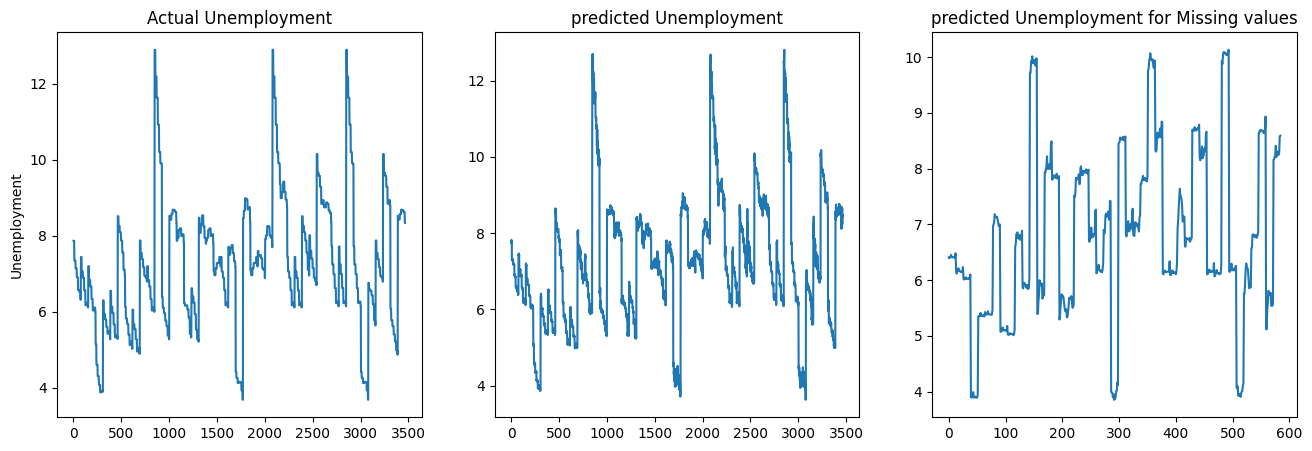

In [201]:
# Plot actual unemployment, predicted unemployment, and predictions for missing values
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.lineplot(cpi_unemp_notnull_df['Unemployment'])
plt.title(f'Actual Unemployment')

plt.subplot(1,3,2)
sns.lineplot(y_pred)
plt.title('predicted Unemployment')

plt.subplot(1,3,3)
sns.lineplot(predicted_unemp)
plt.title('predicted Unemployment for Missing values')
plt.show()

In [202]:
# Fill missing Unemployment values with model predictions
cpi_unemp_null_df['Unemployment'] = predicted_unemp
cpi_unemp_null_df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,66.66,3.386,2298.63,2.00,129.90,55.46,1301.04,NaN,6.406919,0,18,3,5,2013
1,1,1,151315,63.90,3.392,4624.61,83.88,42.38,1618.31,8144.90,NaN,6.390168,0,19,10,5,2013
2,1,1,151315,69.53,3.454,16170.50,92.00,8.32,4127.24,6206.97,NaN,6.414178,0,20,17,5,2013
3,1,1,151315,77.19,3.494,7959.89,178.00,1621.47,3152.57,2938.70,NaN,6.411540,0,21,24,5,2013
4,1,1,151315,78.02,3.466,2369.77,142.45,475.35,45.55,2056.84,NaN,6.451834,0,22,31,5,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,45,2,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,8.308551,0,26,28,6,2013
581,45,2,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,8.249614,0,27,5,7,2013
582,45,2,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,8.287728,0,28,12,7,2013
583,45,2,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,8.581907,0,29,19,7,2013


In [203]:
# Train multiple regression models to predict CPI and display their performance
y = cpi_unemp_notnull_df['CPI']
x = cpi_unemp_notnull_df.drop('CPI', axis =1)

regression_models = regression(x,y)
r_models = regression_models.all_model()
r_models

(2772, 16) (693, 16) (2772,) (693,)


,Model_Name,Train_Mean_Square_Error,Test_Mean_Square_Error,Train_Root_Mean_Square_Error,Test_Root_Mean_Square_Error,Train_Mean_Absolute_Error,Test_Mean_Absolute_Error,Train_R2_Score,Test_R2_Score
0,AdaBoostRegressor,531.0948,512.8800,23.05,22.65,19.9293,19.8121,0.6808,0.6971
1,RandomForestRegressor,2.0426,8.3564,1.43,2.89,0.4299,0.9961,0.9988,0.9951
2,ExtraTreesRegressor,0.0000,4.3355,0.00,2.08,0.0000,1.1903,1.0000,0.9974
3,GradientBoostingRegressor,52.8662,50.5778,7.27,7.11,5.3613,5.3598,0.9682,0.9701
4,HistGradientBoostingRegressor,0.7521,2.9595,0.87,1.72,0.5061,0.7823,0.9995,0.9983
5,DecisionTreeRegressor,0.0000,2.6575,0.00,1.63,0.0000,0.2423,1.0000,0.9984
6,XGBRegressor,0.1428,3.3579,0.38,1.83,0.2614,1.1343,0.9999,0.9980
7,LinearRegression,1136.7365,1138.3789,33.72,33.74,28.6578,28.4127,0.3167,0.3277
8,KNeighborsRegressor,563.6329,875.1654,23.74,29.58,15.4443,19.5685,0.6612,0.4832
9,MLPRegressor,21855.2323,10018.2223,147.84,100.09,72.3377,71.1091,-12.1369,-4.9163


In [204]:
# Train HistGradientBoostingRegressor to predict CPI and evaluate MSE on train and test sets
x_train, x_test, y_train, y_test = regression_models.x_train, regression_models.x_test, regression_models.y_train, regression_models.y_test

cpi_model = HistGradientBoostingRegressor().fit(x_train, y_train)

y_test_pred = cpi_model.predict(x_test) 
y_train_pred = cpi_model.predict(x_train)
data ={
        'Train_Mean_Square_Error': round(mean_squared_error(y_train, y_train_pred),4),
        'Test_Mean_Square_Error': round(mean_squared_error(y_test, y_test_pred),4)}
print(data)

{'Train_Mean_Square_Error': 0.7521, 'Test_Mean_Square_Error': 2.9595}


In [205]:
# Train CPI model on full data and calculate overall MSE
cpi_model = HistGradientBoostingRegressor().fit(x,y)
y_pred = cpi_model.predict(x)

mean_squared_error(y, y_pred)

1.4193234352769577

In [206]:
x_new=cpi_unemp_null_df.drop( 'CPI', axis =1)
predicted_cpi = cpi_model.predict(x_new)

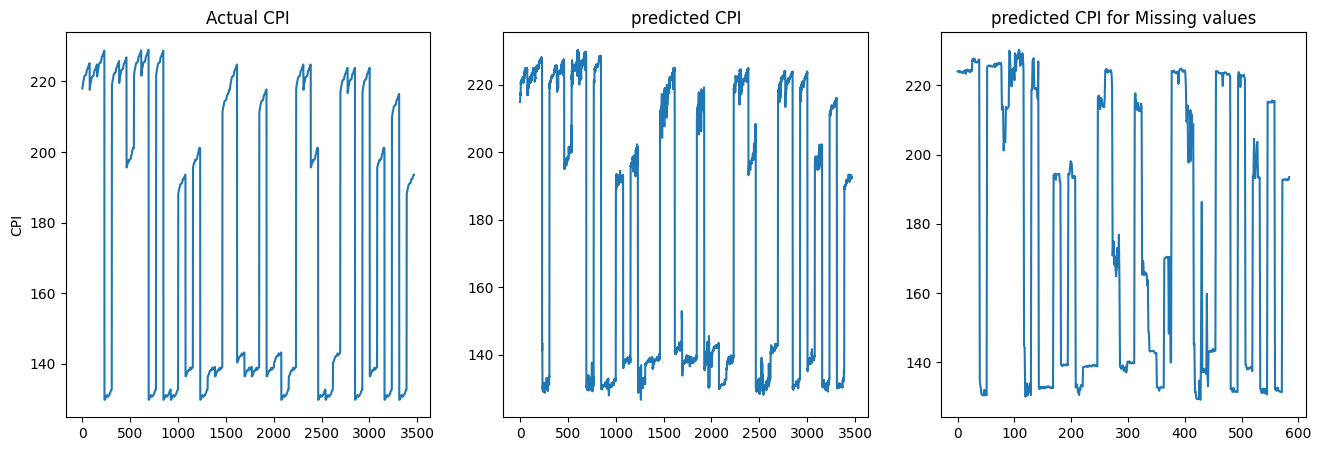

In [207]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.lineplot(cpi_unemp_notnull_df['CPI'])
plt.title(f'Actual CPI')

plt.subplot(1,3,2)
sns.lineplot(y_pred)
plt.title('predicted CPI')

plt.subplot(1,3,3)
sns.lineplot(predicted_cpi)
plt.title('predicted CPI for Missing values')
plt.show()

In [208]:
cpi_unemp_null_df['CPI'] = predicted_cpi
cpi_unemp_null_df.head()

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,66.66,3.386,2298.63,2.00,129.90,55.46,1301.04,223.977274,6.406919,0,18,3,5,2013
1,1,1,151315,63.90,3.392,4624.61,83.88,42.38,1618.31,8144.90,224.044858,6.390168,0,19,10,5,2013
2,1,1,151315,69.53,3.454,16170.50,92.00,8.32,4127.24,6206.97,224.164856,6.414178,0,20,17,5,2013
3,1,1,151315,77.19,3.494,7959.89,178.00,1621.47,3152.57,2938.70,223.706061,6.411540,0,21,24,5,2013
4,1,1,151315,78.02,3.466,2369.77,142.45,475.35,45.55,2056.84,223.856900,6.451834,0,22,31,5,2013


In [209]:
markdown_notnull_df = pd.concat([cpi_unemp_notnull_df, cpi_unemp_null_df], ignore_index=True)
markdown_notnull_df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866000,0,45,11,11,2011
1,1,1,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866000,0,46,18,11,2011
2,1,1,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866000,3,47,25,11,2011
3,1,1,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866000,0,48,2,12,2011
4,1,1,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866000,0,49,9,12,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,45,2,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,192.825518,8.308551,0,26,28,6,2013
4046,45,2,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,192.615082,8.249614,0,27,5,7,2013
4047,45,2,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,192.803314,8.287728,0,28,12,7,2013
4048,45,2,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,192.748473,8.581907,0,29,19,7,2013


### Handling Missing values in MarkDown Columns


In [210]:
markdown_notnull_df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866000,0,45,11,11,2011
1,1,1,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866000,0,46,18,11,2011
2,1,1,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866000,3,47,25,11,2011
3,1,1,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866000,0,48,2,12,2011
4,1,1,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866000,0,49,9,12,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,45,2,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,192.825518,8.308551,0,26,28,6,2013
4046,45,2,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,192.615082,8.249614,0,27,5,7,2013
4047,45,2,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,192.803314,8.287728,0,28,12,7,2013
4048,45,2,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,192.748473,8.581907,0,29,19,7,2013


In [211]:
markdown_null

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number
0,1,A,151315,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,No Holiday,5
1,1,A,151315,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,Super Bowl,6
2,1,A,151315,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,No Holiday,7
3,1,A,151315,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,No Holiday,8
4,1,A,151315,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,No Holiday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,45,B,118221,2011-10-07,55.82,3.583,NaN,NaN,NaN,NaN,NaN,187.483796,8.523,No Holiday,40
4136,45,B,118221,2011-10-14,63.82,3.541,NaN,NaN,NaN,NaN,NaN,187.691748,8.523,No Holiday,41
4137,45,B,118221,2011-10-21,59.60,3.570,NaN,NaN,NaN,NaN,NaN,187.784620,8.523,No Holiday,42
4138,45,B,118221,2011-10-28,51.78,3.569,NaN,NaN,NaN,NaN,NaN,187.877491,8.523,No Holiday,43


In [212]:
markdown_null_df = markdown_null.copy()
markdown_null_df['Day'] = markdown_null['Date'].dt.day
markdown_null_df['Month'] = markdown_null['Date'].dt.month
markdown_null_df['Year'] = markdown_null['Date'].dt.year

markdown_null_df.drop('Date', axis =1, inplace = True)
markdown_null_df.head()

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,No Holiday,5,5,2,2010
1,1,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,Super Bowl,6,12,2,2010
2,1,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,No Holiday,7,19,2,2010
3,1,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,No Holiday,8,26,2,2010
4,1,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,No Holiday,9,5,3,2010


In [213]:
# Coverting categorical data into numerical data
holiday = {'No Holiday':0, 
           'Super Bowl':1,
           'Labor Day':2,
           'Thanksgiving':3,
           'Christmas':4,}
Type = {"A":1, "B":2, "C":3}

markdown_null_df['IsHoliday'] = markdown_null_df["IsHoliday"].map(holiday)
markdown_null_df['Type'] = markdown_null_df["Type"].map(Type)

markdown_null_df.head()

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,5,2,2010
1,1,1,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,1,6,12,2,2010
2,1,1,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,0,7,19,2,2010
3,1,1,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,0,8,26,2,2010
4,1,1,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,0,9,5,3,2010


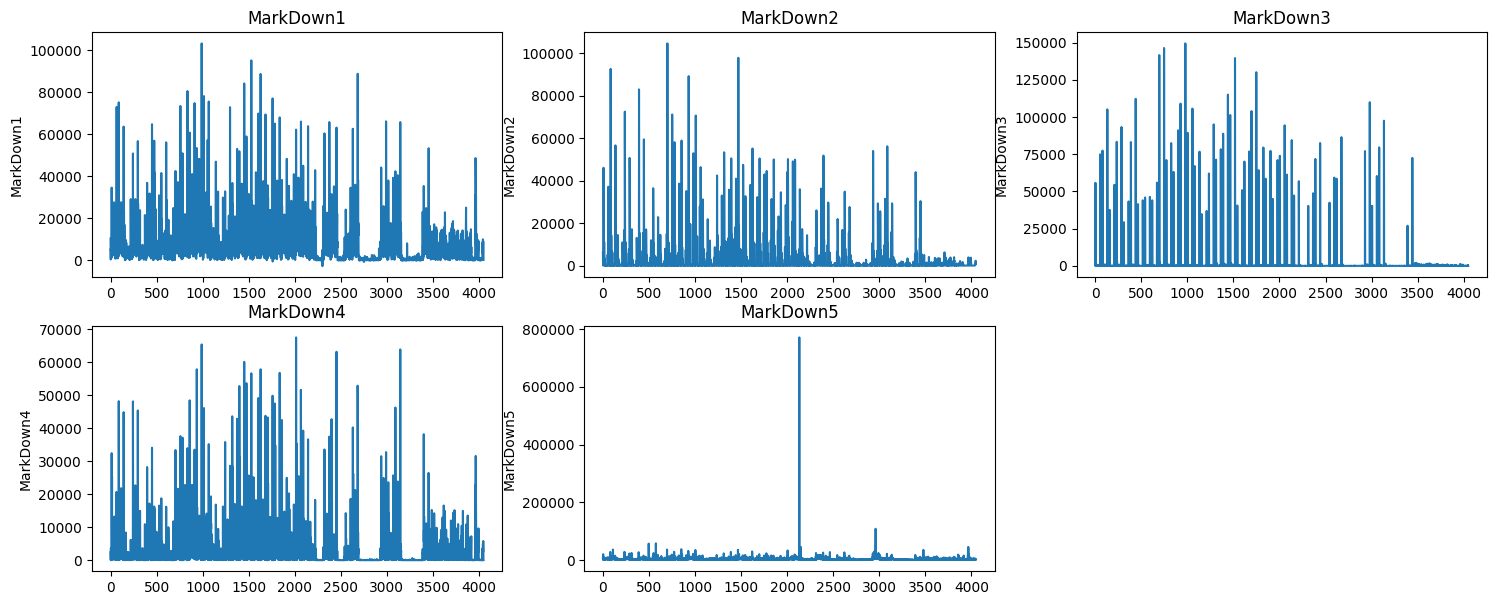

In [ ]:
# Line plots of MarkDown1–5 showing promotional discount values over time; spikes indicate active promotions, while gaps suggest missing or inactive markdown periods.

plt.figure(figsize=(18, 7))

plt.subplot(2, 3, 1)
sns.lineplot(markdown_notnull_df['MarkDown1'])
plt.title(f'MarkDown1')

plt.subplot(2, 3, 2)
sns.lineplot(markdown_notnull_df['MarkDown2'])
plt.title(f'MarkDown2')

plt.subplot(2, 3, 3)
sns.lineplot(markdown_notnull_df['MarkDown3'])
plt.title(f'MarkDown3')

plt.subplot(2, 3, 4)
sns.lineplot(markdown_notnull_df['MarkDown4'])
plt.title(f'MarkDown4')

plt.subplot(2, 3, 5)
sns.lineplot(markdown_notnull_df['MarkDown5'])
plt.title(f'MarkDown5')

plt.show()

In [215]:
y= markdown_notnull_df['MarkDown1']
x = markdown_notnull_df.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'],  axis =1)

In [216]:
regression_models = regression(x,y)
# Apply the 'all_model' method to train and evaluate various regression models
r_models = regression_models.all_model()
r_models

(3240, 12) (810, 12) (3240,) (810,)


,Model_Name,Train_Mean_Square_Error,Test_Mean_Square_Error,Train_Root_Mean_Square_Error,Test_Root_Mean_Square_Error,Train_Mean_Absolute_Error,Test_Mean_Absolute_Error,Train_R2_Score,Test_R2_Score
0,AdaBoostRegressor,8.549437e+07,9.489305e+07,9246.32,9741.31,8201.8363,8557.3248,0.0406,-0.3250
1,RandomForestRegressor,3.527652e+06,2.224394e+07,1878.20,4716.35,978.6132,2875.5898,0.9604,0.6894
2,ExtraTreesRegressor,0.000000e+00,2.151613e+07,0.00,4638.55,0.0000,2780.4259,1.0000,0.6996
3,GradientBoostingRegressor,2.226315e+07,2.262512e+07,4718.38,4756.59,2680.1197,3007.3072,0.7502,0.6841
4,HistGradientBoostingRegressor,8.745250e+06,1.798979e+07,2957.24,4241.44,1706.0225,2651.8116,0.9019,0.7488
5,DecisionTreeRegressor,0.000000e+00,5.250160e+07,0.00,7245.80,0.0000,3825.2660,1.0000,0.2669
6,XGBRegressor,1.193367e+06,1.975853e+07,1092.41,4445.06,738.3113,2806.6136,0.9866,0.7241
7,LinearRegression,6.534021e+07,5.272841e+07,8083.33,7261.43,4670.4662,4531.5544,0.2668,0.2637
8,KNeighborsRegressor,4.604231e+07,6.311110e+07,6785.45,7944.25,3515.7293,4500.2238,0.4833,0.1188
9,MLPRegressor,7.831135e+07,6.248306e+07,8849.37,7904.62,4484.4296,4448.7739,0.1212,0.1275


In [217]:
x_train, x_test, y_train, y_test = regression_models.x_train, regression_models.x_test, regression_models.y_train, regression_models.y_test
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((3240, 12), (810, 12), (3240,), (810,))

In [218]:
model = RandomForestRegressor().fit(x,y)
y_pred =model.predict(x)
print(mean_absolute_error(y_pred, y))

959.6176013580244


In [219]:
y= markdown_notnull_df['MarkDown1']
x = markdown_notnull_df.drop(['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'],  axis =1)

markdown1_model = RandomForestRegressor().fit(x,y)
y_pred =markdown1_model.predict(x)
print(mean_absolute_error(y_pred, y))

x_new = markdown_null_df.drop(['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'],  axis =1)
predicted_markdown1 = markdown1_model.predict(x_new)
markdown_null_df['MarkDown1'] = predicted_markdown1

markdown_null_df.head()

966.3627906666663


,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,21083.6181,NaN,NaN,NaN,NaN,211.096358,8.106,0,5,5,2,2010
1,1,1,151315,38.51,2.548,22203.1759,NaN,NaN,NaN,NaN,211.242170,8.106,1,6,12,2,2010
2,1,1,151315,39.93,2.514,18173.2435,NaN,NaN,NaN,NaN,211.289143,8.106,0,7,19,2,2010
3,1,1,151315,46.63,2.561,15216.2304,NaN,NaN,NaN,NaN,211.319643,8.106,0,8,26,2,2010
4,1,1,151315,46.50,2.625,18096.3674,NaN,NaN,NaN,NaN,211.350143,8.106,0,9,5,3,2010


In [ ]:
# Train model to predict MarkDown2, evaluate MAE, predict missing values, and fill them in dataset
y= markdown_notnull_df['MarkDown2']
x = markdown_notnull_df.drop([ 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'],  axis =1)

markdown2_model = RandomForestRegressor().fit(x,y)
y_pred =markdown2_model.predict(x)
print(mean_absolute_error(y_pred, y))

x_new = markdown_null_df.drop([ 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'],  axis =1)
predicted_markdown2 = markdown2_model.predict(x_new)
markdown_null_df['MarkDown2'] = predicted_markdown2

markdown_null_df.head()

320.8045842469134


,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,NaN,NaN,NaN,211.096358,8.106,0,5,5,2,2010
1,1,1,151315,38.51,2.548,22203.1759,5320.8374,NaN,NaN,NaN,211.242170,8.106,1,6,12,2,2010
2,1,1,151315,39.93,2.514,18173.2435,10339.8667,NaN,NaN,NaN,211.289143,8.106,0,7,19,2,2010
3,1,1,151315,46.63,2.561,15216.2304,9298.4466,NaN,NaN,NaN,211.319643,8.106,0,8,26,2,2010
4,1,1,151315,46.50,2.625,18096.3674,3743.9964,NaN,NaN,NaN,211.350143,8.106,0,9,5,3,2010


In [221]:
y= markdown_notnull_df['MarkDown3']
x = markdown_notnull_df.drop([ 'MarkDown3', 'MarkDown4', 'MarkDown5'],  axis =1)

markdown3_model = RandomForestRegressor().fit(x,y)
y_pred =markdown3_model.predict(x)
print(mean_absolute_error(y_pred, y))

x_new = markdown_null_df.drop(['MarkDown3', 'MarkDown4', 'MarkDown5'],  axis =1)
predicted_markdown3 = markdown3_model.predict(x_new)
markdown_null_df['MarkDown3'] = predicted_markdown3

markdown_null_df.head()

168.83788617283957


,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,NaN,NaN,211.096358,8.106,0,5,5,2,2010
1,1,1,151315,38.51,2.548,22203.1759,5320.8374,218.7134,NaN,NaN,211.242170,8.106,1,6,12,2,2010
2,1,1,151315,39.93,2.514,18173.2435,10339.8667,307.3915,NaN,NaN,211.289143,8.106,0,7,19,2,2010
3,1,1,151315,46.63,2.561,15216.2304,9298.4466,202.1024,NaN,NaN,211.319643,8.106,0,8,26,2,2010
4,1,1,151315,46.50,2.625,18096.3674,3743.9964,213.8234,NaN,NaN,211.350143,8.106,0,9,5,3,2010


In [ ]:
# Train model to predict MarkDown2, evaluate MAE, predict missing values, and fill them in dataset
y= markdown_notnull_df['MarkDown4']
x = markdown_notnull_df.drop(['MarkDown4', 'MarkDown5'],  axis =1)

markdown4_model = RandomForestRegressor().fit(x,y)
y_pred =markdown4_model.predict(x)
print(mean_absolute_error(y_pred, y))

x_new = markdown_null_df.drop(['MarkDown4', 'MarkDown5'],  axis =1)
predicted_markdown4 = markdown4_model.predict(x_new)
markdown_null_df['MarkDown4'] = predicted_markdown4

markdown_null_df.head()

415.6296580987656


,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,NaN,211.096358,8.106,0,5,5,2,2010
1,1,1,151315,38.51,2.548,22203.1759,5320.8374,218.7134,19603.1023,NaN,211.242170,8.106,1,6,12,2,2010
2,1,1,151315,39.93,2.514,18173.2435,10339.8667,307.3915,14548.0346,NaN,211.289143,8.106,0,7,19,2,2010
3,1,1,151315,46.63,2.561,15216.2304,9298.4466,202.1024,9205.0268,NaN,211.319643,8.106,0,8,26,2,2010
4,1,1,151315,46.50,2.625,18096.3674,3743.9964,213.8234,13323.1245,NaN,211.350143,8.106,0,9,5,3,2010


In [ ]:
# Train model to predict MarkDown2, evaluate MAE, predict missing values, and fill them in dataset
y= markdown_notnull_df['MarkDown5']
x = markdown_notnull_df.drop('MarkDown5',  axis =1)

markdown5_model = RandomForestRegressor().fit(x,y)
y_pred =markdown5_model.predict(x)
print(mean_absolute_error(y_pred, y))

x_new = markdown_null_df.drop('MarkDown5',  axis =1)
predicted_markdown5 = markdown5_model.predict(x_new)
markdown_null_df['MarkDown5'] = predicted_markdown5

markdown_null_df.head()

786.4465515555554


,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106,0,5,5,2,2010
1,1,1,151315,38.51,2.548,22203.1759,5320.8374,218.7134,19603.1023,6579.0946,211.242170,8.106,1,6,12,2,2010
2,1,1,151315,39.93,2.514,18173.2435,10339.8667,307.3915,14548.0346,5704.5196,211.289143,8.106,0,7,19,2,2010
3,1,1,151315,46.63,2.561,15216.2304,9298.4466,202.1024,9205.0268,7275.9230,211.319643,8.106,0,8,26,2,2010
4,1,1,151315,46.50,2.625,18096.3674,3743.9964,213.8234,13323.1245,6256.0472,211.350143,8.106,0,9,5,3,2010


In [224]:
feature_notnull_df = pd.concat([markdown_null_df, markdown_notnull_df], axis = 0, ignore_index=True)
feature_notnull_df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010
1,1,1,151315,38.51,2.548,22203.1759,5320.8374,218.7134,19603.1023,6579.0946,211.242170,8.106000,1,6,12,2,2010
2,1,1,151315,39.93,2.514,18173.2435,10339.8667,307.3915,14548.0346,5704.5196,211.289143,8.106000,0,7,19,2,2010
3,1,1,151315,46.63,2.561,15216.2304,9298.4466,202.1024,9205.0268,7275.9230,211.319643,8.106000,0,8,26,2,2010
4,1,1,151315,46.50,2.625,18096.3674,3743.9964,213.8234,13323.1245,6256.0472,211.350143,8.106000,0,9,5,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2,118221,76.05,3.639,4842.2900,975.0300,3.0000,2449.9700,3169.6900,192.825518,8.308551,0,26,28,6,2013
8186,45,2,118221,77.50,3.614,9090.4800,2268.5800,582.7400,5797.4700,1514.9300,192.615082,8.249614,0,27,5,7,2013
8187,45,2,118221,79.37,3.614,3789.9400,1827.3100,85.7200,744.8400,2150.3600,192.803314,8.287728,0,28,12,7,2013
8188,45,2,118221,82.84,3.737,2961.4900,1047.0700,204.1900,363.0000,1059.4600,192.748473,8.581907,0,29,19,7,2013


### Merging Sales DataFrame

In [ ]:
# Convert 'Date' column in sales_df1 to datetime format
sales_df1['Date'] = pd.to_datetime(sales_df1['Date'], format= '%d/%m/%Y')
sales_df1.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
# Convert 'Date' column in sales_df2 to datetime format
sales_df2['Date'] = pd.to_datetime(sales_df2['Date'], format= '%Y-%m-%d')
sales_df2.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [ ]:

# Combine sales_df1 and sales_df2 into a single DataFrame
sales = pd.concat([sales_df1, sales_df2], ignore_index=True)
sales

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
536629,45,98,2013-06-28,NaN,False
536630,45,98,2013-07-05,NaN,False
536631,45,98,2013-07-12,NaN,False
536632,45,98,2013-07-19,NaN,False


In [228]:
sales.Weekly_Sales.isna().value_counts()

False    421570
True     115064
Name: Weekly_Sales, dtype: int64

In [ ]:
# Reconstruct 'Date' column from Year, Month, Day in feature_notnull_df1
feature_notnull_df1 = feature_notnull_df.copy()
feature_notnull_df1['Date'] = pd.to_datetime(feature_notnull_df1[['Year', 'Month', 'Day']])
feature_notnull_df1


,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year,Date
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010,2010-02-05
1,1,1,151315,38.51,2.548,22203.1759,5320.8374,218.7134,19603.1023,6579.0946,211.242170,8.106000,1,6,12,2,2010,2010-02-12
2,1,1,151315,39.93,2.514,18173.2435,10339.8667,307.3915,14548.0346,5704.5196,211.289143,8.106000,0,7,19,2,2010,2010-02-19
3,1,1,151315,46.63,2.561,15216.2304,9298.4466,202.1024,9205.0268,7275.9230,211.319643,8.106000,0,8,26,2,2010,2010-02-26
4,1,1,151315,46.50,2.625,18096.3674,3743.9964,213.8234,13323.1245,6256.0472,211.350143,8.106000,0,9,5,3,2010,2010-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2,118221,76.05,3.639,4842.2900,975.0300,3.0000,2449.9700,3169.6900,192.825518,8.308551,0,26,28,6,2013,2013-06-28
8186,45,2,118221,77.50,3.614,9090.4800,2268.5800,582.7400,5797.4700,1514.9300,192.615082,8.249614,0,27,5,7,2013,2013-07-05
8187,45,2,118221,79.37,3.614,3789.9400,1827.3100,85.7200,744.8400,2150.3600,192.803314,8.287728,0,28,12,7,2013,2013-07-12
8188,45,2,118221,82.84,3.737,2961.4900,1047.0700,204.1900,363.0000,1059.4600,192.748473,8.581907,0,29,19,7,2013,2013-07-19


In [230]:
df = feature_notnull_df1.merge(sales, on = ['Store', 'Date'],how = 'inner')
df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,Unemployment,IsHoliday_x,Week_Number,Day,Month,Year,Date,Dept,Weekly_Sales,IsHoliday_y
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,...,8.106000,0,5,5,2,2010,2010-02-05,1,24924.50,False
1,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,...,8.106000,0,5,5,2,2010,2010-02-05,2,50605.27,False
2,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,...,8.106000,0,5,5,2,2010,2010-02-05,3,13740.12,False
3,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,...,8.106000,0,5,5,2,2010,2010-02-05,4,39954.04,False
4,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,...,8.106000,0,5,5,2,2010,2010-02-05,5,32229.38,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,...,8.590008,0,30,26,7,2013,2013-07-26,93,NaN,False
536630,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,...,8.590008,0,30,26,7,2013,2013-07-26,94,NaN,False
536631,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,...,8.590008,0,30,26,7,2013,2013-07-26,95,NaN,False
536632,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,...,8.590008,0,30,26,7,2013,2013-07-26,97,NaN,False


In [ ]:
# Rename 'IsHoliday_x' to 'IsHoliday' and drop 'IsHoliday_y' & 'Date' columns
df.rename(columns = {'IsHoliday_x':'IsHoliday'}, inplace = True)
df.drop(columns=['IsHoliday_y', 'Date'],axis =1, inplace = True)
df.columns

Index(['Store', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday', 'Week_Number', 'Day', 'Month', 'Year',
       'Dept', 'Weekly_Sales'],
      dtype='object')

In [ ]:
# Count missing vs non-missing values in 'Weekly_Sales' column
df.Weekly_Sales.isna().value_counts()

False    421570
True     115064
Name: Weekly_Sales, dtype: int64

In [ ]:
# Filter rows where any MarkDown column has negative values
df[(df.MarkDown1<0) | (df.MarkDown2<0) |(df.MarkDown3<0) | (df.MarkDown4<0) | (df.MarkDown5<0)]

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year,Dept,Weekly_Sales
182017,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,1,11318.28
182018,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,2,24949.59
182019,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,3,6428.37
182020,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,4,14087.63
182021,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,5,8883.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504121,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,94,NaN
504122,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,95,NaN
504123,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,96,NaN
504124,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,97,NaN


In [ ]:

# Create 'Is_MarkUp' flag for rows with any negative MarkDown values
df['Is_MarkUp'] = np.where((df.MarkDown1<0) | (df.MarkDown2<0) |(df.MarkDown3<0) | (df.MarkDown4<0) | (df.MarkDown5<0),
                                    1, 0)
df[(df.MarkDown1<0) | (df.MarkDown2<0) |(df.MarkDown3<0) | (df.MarkDown4<0) | (df.MarkDown5<0)]

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year,Dept,Weekly_Sales,Is_MarkUp
182017,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,1,11318.28,1
182018,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,2,24949.59,1
182019,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,3,6428.37,1
182020,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,4,14087.63,1
182021,29,2,93638,53.63,4.078,7645.1086,-4.2004,190.9268,2862.175,3790.3179,134.514367,9.966000,0,18,6,5,2011,5,8883.10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504121,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,94,NaN,1
504122,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,95,NaN,1
504123,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,96,NaN,1
504124,7,2,70713,50.70,3.870,2350.7800,-7.7600,91.5900,166.860,540.8900,203.766543,7.140499,0,22,31,5,2013,97,NaN,1


In [ ]:
# Split dataset into train and test sets based on presence of Weekly_Sales, and check missing counts
train_df = df[df.Weekly_Sales.isna()==False]
test_df = df[df.Weekly_Sales.isna()==True]
train_df.Weekly_Sales.isna().sum(), test_df.Weekly_Sales.isna().sum()

(0, 115064)

In [ ]:
# Train RandomForest model to predict Weekly_Sales and evaluate MAE on train and test sets
y = train_df['Weekly_Sales']
x = train_df.drop('Weekly_Sales', axis = 1)

x_train,x_test, y_train,y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)
model = RandomForestRegressor().fit(x_train, y_train)

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
print('train ', mean_absolute_error(y_train_pred, y_train))
print('test ', mean_absolute_error(y_test_pred, y_test))

train  509.1445118414498
test  1382.826632648196


In [237]:
x_new = test_df.drop('Weekly_Sales', axis =1)

predicted_weekly_sales = model.predict(x_new)

In [238]:
test_df['Weekly_Sales'] = predicted_weekly_sales

C:\Users\praka\AppData\Local\Temp\ipykernel_19648\444904689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Weekly_Sales'] = predicted_weekly_sales


In [ ]:
x_test1 = train_df.drop('Weekly_Sales', axis =1)
y_test1 = train_df['Weekly_Sales']
y_test1[400000:400010]
# x_test1[100000:100010]x_test1 = train_df.drop('Weekly_Sales', axis =1)
y_test1 = train_df['Weekly_Sales']
y_test1[400000:400010]
# x_test1[100000:100010]

465760    104156.74
465761     38718.60
465762     16020.70
465763     15075.99
465764     35548.17
465765      4403.97
465766     54178.36
465767     30210.48
465768      5768.98
465769     14269.09
Name: Weekly_Sales, dtype: float64

In [ ]:
# Prepare full training data for testing predictions and inspect a slice of Weekly_Sales
x_test1 = train_df.drop('Weekly_Sales', axis =1)
y_test1 = train_df['Weekly_Sales']
y_test1[400000:400010]
# x_test1[100000:100010]

array([92409.699 , 38965.8581, 16872.0407, 17352.9579, 31012.8903,
        4296.9713, 55002.6044, 29755.8596,  5598.6788, 12291.5678])

In [ ]:
# Inspect Weekly_Sales values from index 100000 to 100009 in the training data
x_test1 = train_df.drop('Weekly_Sales', axis =1)
y_test1 = train_df['Weekly_Sales']
y_test1[100000:100010]

100000       58.79
100001     2355.51
100002    12292.33
100003    30476.47
100004     6678.32
100005    18707.80
100006     8671.25
100007     5980.17
100008    13044.46
100009    13908.02
Name: Weekly_Sales, dtype: float64

In [ ]:
# Predict Weekly_Sales for indices 100000 to 100009 using the trained model
model.predict(x_test1[100000:100010])

array([   94.2001,  2415.4113, 11415.7028, 29761.6707,  7258.1232,
       18333.2767, 10635.6183,  5955.3334, 13450.8724, 14323.7536])

In [243]:
final_df = pd.concat([train_df, test_df], axis =0, ignore_index = True)
final_df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year,Dept,Weekly_Sales,Is_MarkUp
0,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010,1,24924.5000,0
1,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010,2,50605.2700,0
2,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010,3,13740.1200,0
3,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010,4,39954.0400,0
4,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,0,5,5,2,2010,5,32229.3800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,0,30,26,7,2013,93,3373.8589,0
536630,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,0,30,26,7,2013,94,4307.5731,0
536631,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,0,30,26,7,2013,95,56405.5206,0
536632,45,2,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,0,30,26,7,2013,97,6375.3472,0


In [244]:
# Coverting the numerical data into Categorical data for categorical column. 
holiday = {0: 'No Holiday', 
           1: 'Super Bowl',
           2: 'Labor Day',
           3: 'Thanksgiving',
           4: 'Christmas',}
Type = {1: "A", 2: "B", 3: "C"}

final_df['IsHoliday'] = final_df['IsHoliday'].map(holiday)
final_df['Type'] = final_df['Type'].map(Type)
final_df

,Store,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Week_Number,Day,Month,Year,Dept,Weekly_Sales,Is_MarkUp
0,1,A,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,No Holiday,5,5,2,2010,1,24924.5000,0
1,1,A,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,No Holiday,5,5,2,2010,2,50605.2700,0
2,1,A,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,No Holiday,5,5,2,2010,3,13740.1200,0
3,1,A,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,No Holiday,5,5,2,2010,4,39954.0400,0
4,1,A,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,211.096358,8.106000,No Holiday,5,5,2,2010,5,32229.3800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,B,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,No Holiday,30,26,7,2013,93,3373.8589,0
536630,45,B,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,No Holiday,30,26,7,2013,94,4307.5731,0
536631,45,B,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,No Holiday,30,26,7,2013,95,56405.5206,0
536632,45,B,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,193.491386,8.590008,No Holiday,30,26,7,2013,97,6375.3472,0


In [245]:
final_df.isna().sum()

Store           0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
Week_Number     0
Day             0
Month           0
Year            0
Dept            0
Weekly_Sales    0
Is_MarkUp       0
dtype: int64

In [ ]:
# Select relevant features and target column from final_df for the final dataset
final = final_df[['Store', 'Type', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5','Is_MarkUp',
           'Week_Number',  'IsHoliday', 'CPI', 'Unemployment', 'Day', 'Month', 'Year', 'Weekly_Sales' ]]
final

,Store,Type,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Is_MarkUp,Week_Number,IsHoliday,CPI,Unemployment,Day,Month,Year,Weekly_Sales
0,1,A,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,24924.5000
1,1,A,2,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,50605.2700
2,1,A,3,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,13740.1200
3,1,A,4,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,39954.0400
4,1,A,5,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,32229.3800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,B,93,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,3373.8589
536630,45,B,94,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,4307.5731
536631,45,B,95,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,56405.5206
536632,45,B,97,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,6375.3472


### SAVING DATASET

In [ ]:
final.to_csv(r'dataset/Final_dataset.csv', index = False)

In [23]:
combined_df =pd.read_csv(r'dataset/Final_dataset.csv')
combined_df

,Store,Type,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Is_MarkUp,Week_Number,IsHoliday,CPI,Unemployment,Day,Month,Year,Weekly_Sales
0,1,A,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,24924.5000
1,1,A,2,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,50605.2700
2,1,A,3,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,13740.1200
3,1,A,4,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,39954.0400
4,1,A,5,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,32229.3800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,B,93,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,3373.8589
536630,45,B,94,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,4307.5731
536631,45,B,95,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,56405.5206
536632,45,B,97,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,6375.3472


## 📊 Exploratory Data Analysis (EDA) on Processed Data

Post-cleaning and feature engineering, EDA was repeated on the processed dataset (`Combined_dataset.csv`) to validate data quality and understand feature-target relationships.

Key steps included:
- Checking for any remaining missing values
- Visualizing distributions of key features (Temperature, CPI, MarkDowns, Weekly_Sales)
- Plotting correlation heatmaps to understand relationships between engineered features
- Performing scatter plots of `Weekly_Sales` vs numeric features to detect patterns
- Using boxplots to compare `Weekly_Sales` across categorical variables like Store `Type` and `IsHoliday`

This EDA confirmed that imputed and engineered features were well-formed and meaningful for modeling.


In [27]:
# Load processed dataset
df = pd.read_csv('dataset/Final_dataset.csv')

# Map categorical fields if numeric
holiday = {0: 'No Holiday', 1: 'Super Bowl', 2: 'Labor Day', 3: 'Thanksgiving', 4: 'Christmas'}
Type = {1: "A", 2: "B", 3: "C"}
df['IsHoliday'] = df['IsHoliday'].map(holiday)
df['Type'] = df['Type'].map(Type)

print("✅ Missing Values (Post-Cleaning):")
print(df.isna().sum())


✅ Missing Values (Post-Cleaning):
Store                0
Type            536634
Dept                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1            0
MarkDown2            0
MarkDown3            0
MarkDown4            0
MarkDown5            0
Is_MarkUp            0
Week_Number          0
IsHoliday       536634
CPI                  0
Unemployment         0
Day                  0
Month                0
Year                 0
Weekly_Sales         0
dtype: int64


📊 Final Distributions (Histograms):


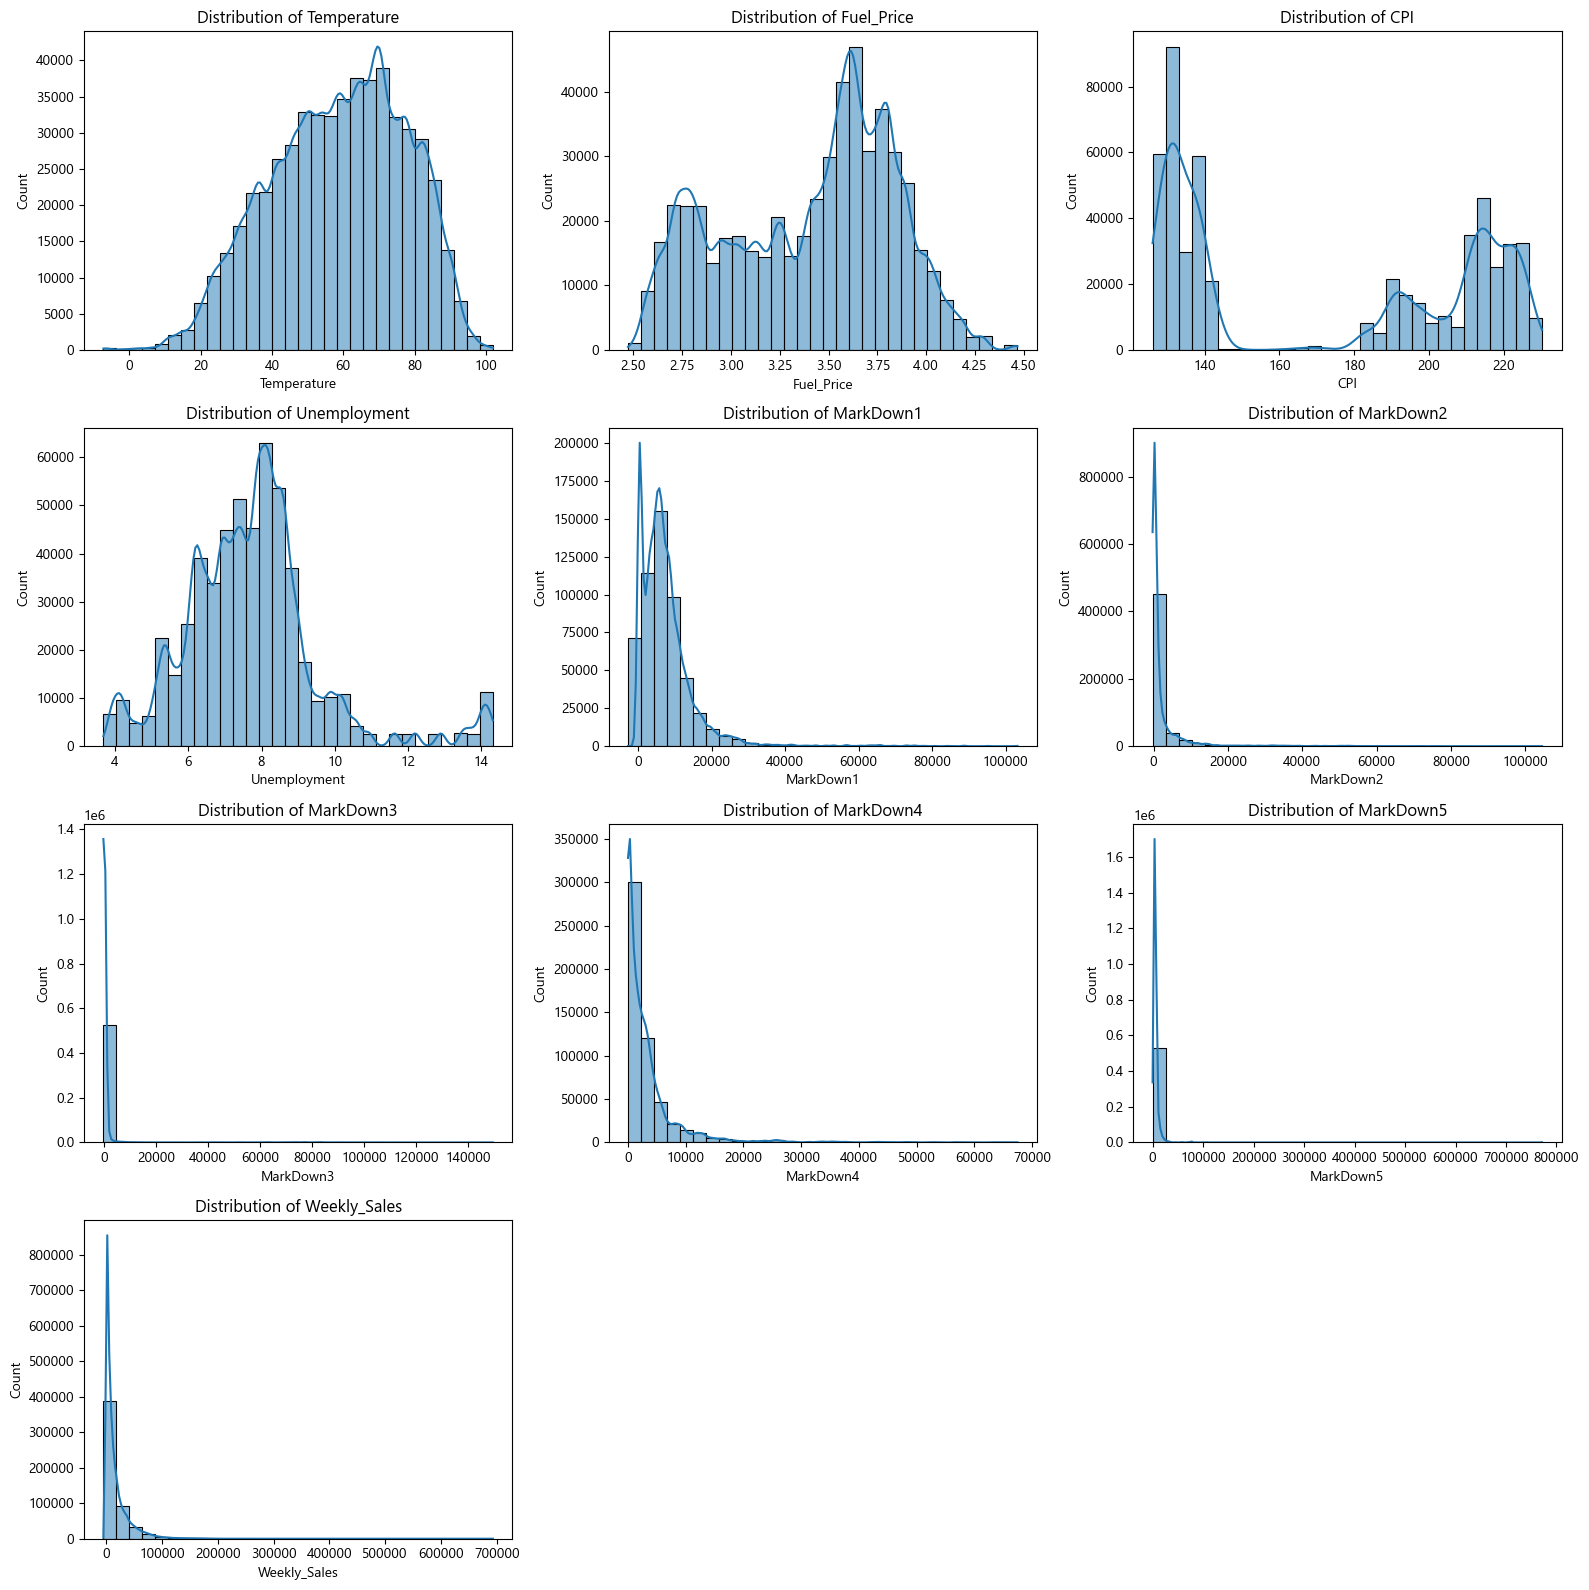

In [28]:
final_num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                  'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                  'Weekly_Sales']

# --- FINAL DISTRIBUTIONS ---
print("📊 Final Distributions (Histograms):")
ncols = 3
nrows = -(-len(final_num_cols) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
for i, col in enumerate(final_num_cols):
    ax = axes.flat[i]
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes.flat[j])
plt.tight_layout()
plt.show()


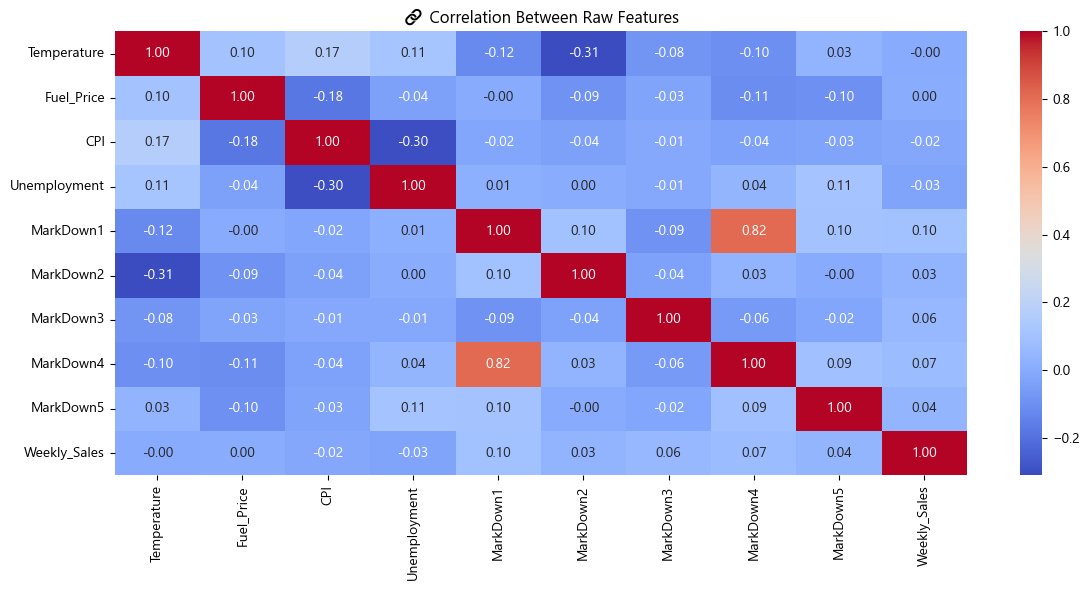

In [29]:
# --- FINAL CORRELATION ---


import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
sns.heatmap(df[final_num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("🔗 Correlation Between Raw Features")
plt.tight_layout()
plt.show()


🎯 Weekly_Sales vs Numerical Features:


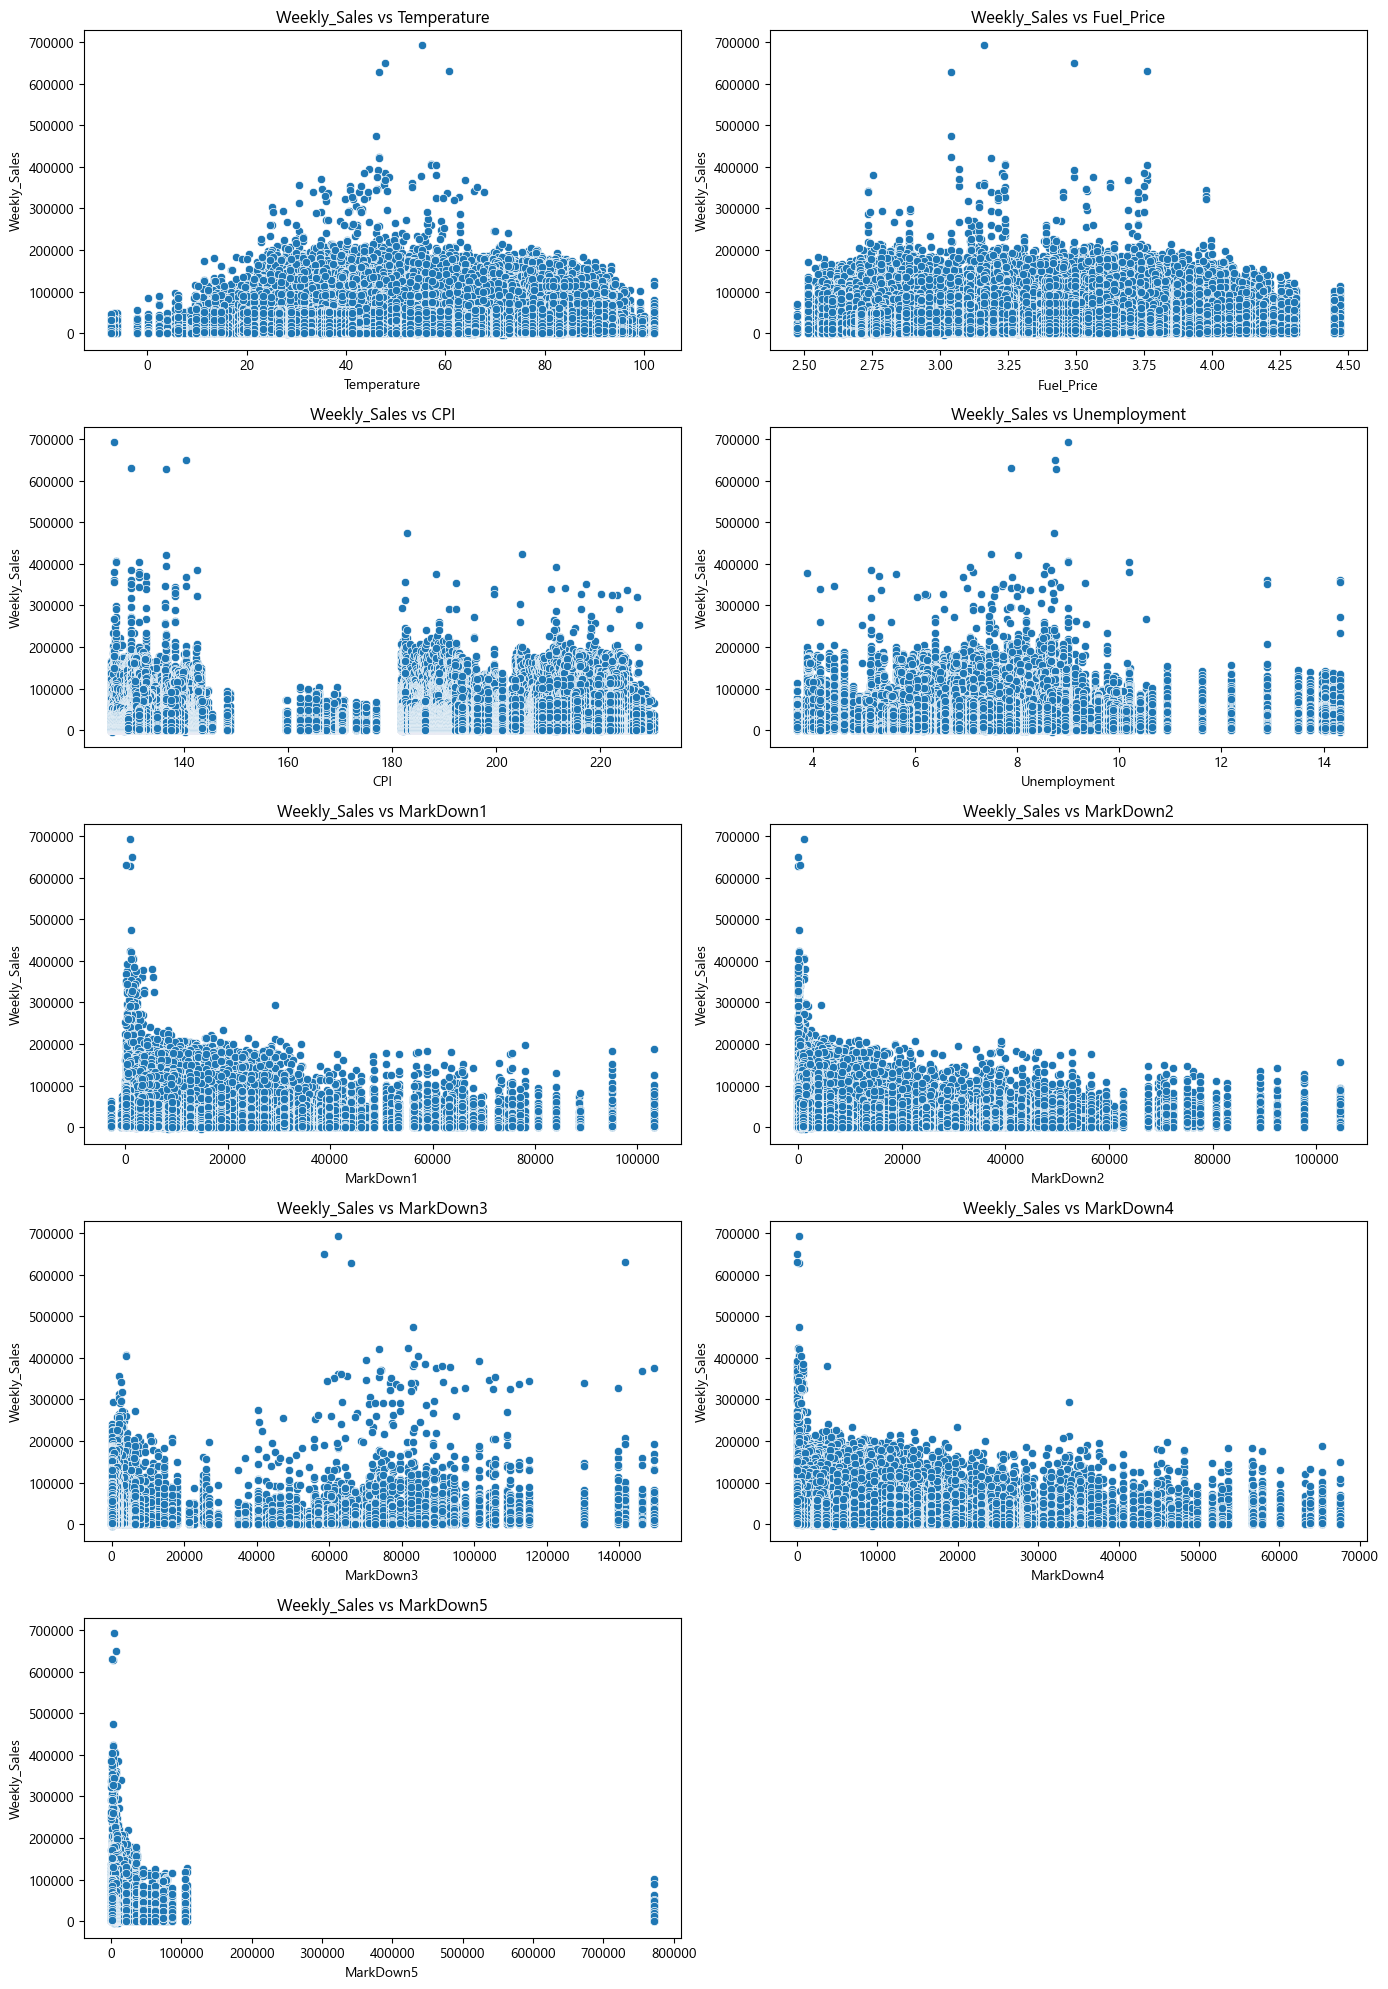

In [30]:
# --- TARGET vs NUMERICAL FEATURES (SCATTER) ---
print("🎯 Weekly_Sales vs Numerical Features:")
num_features = [col for col in final_num_cols if col != 'Weekly_Sales']
ncols = 2
nrows = -(-len(num_features) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
for i, col in enumerate(num_features):
    ax = axes.flat[i]
    sns.scatterplot(data=df, x=col, y='Weekly_Sales', ax=ax)
    ax.set_title(f'Weekly_Sales vs {col}')
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes.flat[j])
plt.tight_layout()
plt.show()

✅ Rows available after filtering: 536634
Unique Types: ['A' 'B' 'C']
Unique Holidays: ['No Holiday' 'Super Bowl' 'Labor Day' 'Thanksgiving' 'Christmas']


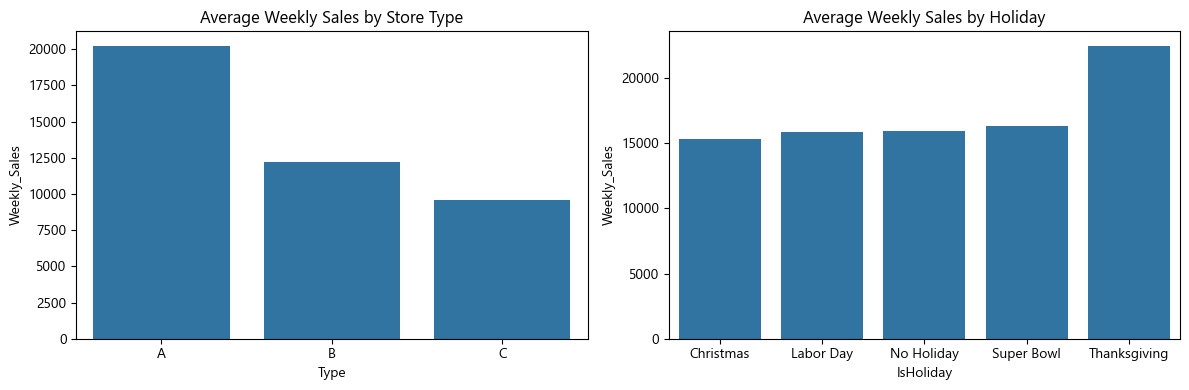

In [38]:

# Load processed dataset
df = pd.read_csv('dataset/Final_dataset.csv')

# Step 1: Check for column presence
assert 'IsHoliday' in df.columns
assert 'Type' in df.columns
assert 'Weekly_Sales' in df.columns

# Step 2: Map categorical values if needed
if df['IsHoliday'].dtype in ['int64', 'float64']:
    holiday = {0: 'No Holiday', 1: 'Super Bowl', 2: 'Labor Day', 3: 'Thanksgiving', 4: 'Christmas'}
    df['IsHoliday'] = df['IsHoliday'].map(holiday)

if df['Type'].dtype in ['int64', 'float64']:
    store_type_map = {1: "A", 2: "B", 3: "C"}
    df['Type'] = df['Type'].map(store_type_map)

# Step 3: Drop rows with missing key values
df_boxplot = df.dropna(subset=['Weekly_Sales', 'IsHoliday', 'Type'])

# Debug: Check if data is present
print("✅ Rows available after filtering:", df_boxplot.shape[0])
print("Unique Types:", df_boxplot['Type'].unique())
print("Unique Holidays:", df_boxplot['IsHoliday'].unique())

# If no rows available, there's nothing to plot
if df_boxplot.shape[0] == 0:
    print("❌ No data to plot after cleaning. Check your input data.")
else:
   
    # Step 4A: (Alternative) Use mean bar plots for categorical features
    avg_type = df_boxplot.groupby('Type')['Weekly_Sales'].mean().reset_index()
    avg_holiday = df_boxplot.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(data=avg_type, x='Type', y='Weekly_Sales', ax=axes[0])
    axes[0].set_title('Average Weekly Sales by Store Type')

    sns.barplot(data=avg_holiday, x='IsHoliday', y='Weekly_Sales', ax=axes[1])
    axes[1].set_title('Average Weekly Sales by Holiday')

    plt.tight_layout()
    plt.show()


C:\Users\praka\AppData\Local\Temp\ipykernel_23516\2148339332.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_m2_corr = df.drop(columns=['Day', 'Month', 'Year', 'Store', 'Dept']).dropna().corr()


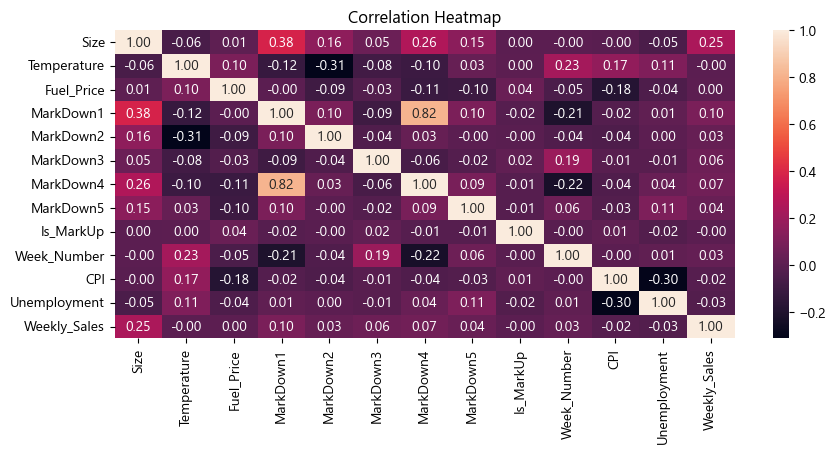

In [40]:
# Calculate the correlation matrix

df_m2_corr = df.drop(columns=['Day', 'Month', 'Year', 'Store', 'Dept']).dropna().corr()

# Create a heatmap
plt.figure(figsize=(10, 4))  # Adjust the figure size if needed
sns.heatmap(df_m2_corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [42]:
# Check the number of missing values in each column of the DataFrame

df.isna().sum()

Store           0
Type            0
Dept            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
Is_MarkUp       0
Week_Number     0
IsHoliday       0
CPI             0
Unemployment    0
Day             0
Month           0
Year            0
Weekly_Sales    0
dtype: int64

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,536634.0,22.208621,12.790580,1.000,11.0000,22.000000,33.000000,45.000000
Dept,536634.0,44.277301,30.527358,1.000,18.0000,37.000000,74.000000,99.000000
Size,536634.0,136678.550960,61007.711800,34875.000,93638.0000,140167.000000,202505.000000,219622.000000
Temperature,536634.0,58.771762,18.678716,-7.290,45.2500,60.060000,73.230000,101.950000
Fuel_Price,536634.0,3.408310,0.430861,2.472,3.0410,3.523000,3.744000,4.468000
MarkDown1,536634.0,7463.440654,7622.994956,-2781.450,2955.5600,6038.079100,9669.108500,103184.980000
MarkDown2,536634.0,2470.236902,7169.238819,-265.760,48.2000,352.587700,1514.565600,104519.540000
MarkDown3,536634.0,1320.940903,9291.933198,-179.260,16.7400,109.928100,197.706500,149483.310000
MarkDown4,536634.0,3456.789243,5725.833935,0.000,375.2200,1784.942800,4023.441100,67474.850000
MarkDown5,536634.0,5458.225217,10547.036170,-185.170,2365.6300,4346.680000,6558.105600,771448.100000


## Milestone 3 - Version 2 (Week 6)
## Model Performance Metrics
- Feature selection & engineering.
- Model training & validation.
- Approve models & hyperparameters.


### Model Training Summary

- Predicted **Weekly_Sales** using a regression model.
- Encoded categorical features and split data into train/test sets.
- Trained **Random Forest, XGBoost, and Linear Regression**.
- Evaluated using **R², MAE, and MSE**.
- **Random Forest performed best** and was selected.
- Saved the final model for future use. 🚀

In [ ]:
# Import Required libraries
import pandas as pd
import numpy as np
from scipy.stats import skew, randint
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression


from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  r2_score

import joblib
import pickle

In [6]:
df = pd.read_csv(r'dataset/Final_dataset.csv')
df

,Store,Type,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Is_MarkUp,Week_Number,IsHoliday,CPI,Unemployment,Day,Month,Year,Weekly_Sales
0,1,A,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,24924.5000
1,1,A,2,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,50605.2700
2,1,A,3,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,13740.1200
3,1,A,4,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,39954.0400
4,1,A,5,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,No Holiday,211.096358,8.106000,5,2,2010,32229.3800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,B,93,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,3373.8589
536630,45,B,94,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,4307.5731
536631,45,B,95,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,56405.5206
536632,45,B,97,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,No Holiday,193.491386,8.590008,26,7,2013,6375.3472


In [7]:
# Christmas holiday introduces as the last days of the year. But people generally shop at 51th week.
# So, when we look at the total sales of holidays, Thankgiving has higher sales between them which was assigned by Walmart.

df['IsHoliday'] = np.where(df['Week_Number'] == 6, 'Super Bowl',
                                    np.where(df['Week_Number'] == 36, 'Labor Day',
                                    np.where(df['Week_Number'] == 47, 'Thanksgiving',
                                    np.where(df['Week_Number'] == 51, 'Christmas',  'No Holiday'))))

In [8]:
# Converting Categorical data into Numerical data.


Type = {'A':1, "B":2, 'C':3}
holiday = {'No Holiday':0, 'Super Bowl':1, 'Labor Day':2, 'Thanksgiving':3, 'Christmas':4}

df['Type'] = df['Type'].map(Type).astype(int)
df['IsHoliday'] = df['IsHoliday'].map(holiday).astype(int)

df.head()


,Store,Type,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Is_MarkUp,Week_Number,IsHoliday,CPI,Unemployment,Day,Month,Year,Weekly_Sales
0,1,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106,5,2,2010,24924.50
1,1,1,2,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106,5,2,2010,50605.27
2,1,1,3,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106,5,2,2010,13740.12
3,1,1,4,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106,5,2,2010,39954.04
4,1,1,5,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106,5,2,2010,32229.38


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Type          536634 non-null  int32  
 2   Dept          536634 non-null  int64  
 3   Size          536634 non-null  int64  
 4   Temperature   536634 non-null  float64
 5   Fuel_Price    536634 non-null  float64
 6   MarkDown1     536634 non-null  float64
 7   MarkDown2     536634 non-null  float64
 8   MarkDown3     536634 non-null  float64
 9   MarkDown4     536634 non-null  float64
 10  MarkDown5     536634 non-null  float64
 11  Is_MarkUp     536634 non-null  int64  
 12  Week_Number   536634 non-null  int64  
 13  IsHoliday     536634 non-null  int32  
 14  CPI           536634 non-null  float64
 15  Unemployment  536634 non-null  float64
 16  Day           536634 non-null  int64  
 17  Month         536634 non-null  int64  
 18  Year

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,536634.0,22.208621,12.790580,1.000,11.0000,22.000000,33.000000,45.000000
Type,536634.0,1.590516,0.666882,1.000,1.0000,1.000000,2.000000,3.000000
Dept,536634.0,44.277301,30.527358,1.000,18.0000,37.000000,74.000000,99.000000
Size,536634.0,136678.550960,61007.711800,34875.000,93638.0000,140167.000000,202505.000000,219622.000000
Temperature,536634.0,58.771762,18.678716,-7.290,45.2500,60.060000,73.230000,101.950000
Fuel_Price,536634.0,3.408310,0.430861,2.472,3.0410,3.523000,3.744000,4.468000
MarkDown1,536634.0,7463.440654,7622.994956,-2781.450,2955.5600,6038.079100,9669.108500,103184.980000
MarkDown2,536634.0,2470.236902,7169.238819,-265.760,48.2000,352.587700,1514.565600,104519.540000
MarkDown3,536634.0,1320.940903,9291.933198,-179.260,16.7400,109.928100,197.706500,149483.310000
MarkDown4,536634.0,3456.789243,5725.833935,0.000,375.2200,1784.942800,4023.441100,67474.850000


In [11]:
# Idendifying Skewness value
df.skew()

Store            0.077555
Type             0.692920
Dept             0.359150
Size            -0.325016
Temperature     -0.267460
Fuel_Price      -0.313840
MarkDown1        3.871081
MarkDown2        6.246687
MarkDown3        9.320734
MarkDown4        4.518228
MarkDown5       51.861051
Is_MarkUp       13.107481
Week_Number      0.161594
IsHoliday        4.333342
CPI              0.081664
Unemployment     1.029223
Day              0.011278
Month            0.151850
Year             0.130470
Weekly_Sales     3.260125
dtype: float64

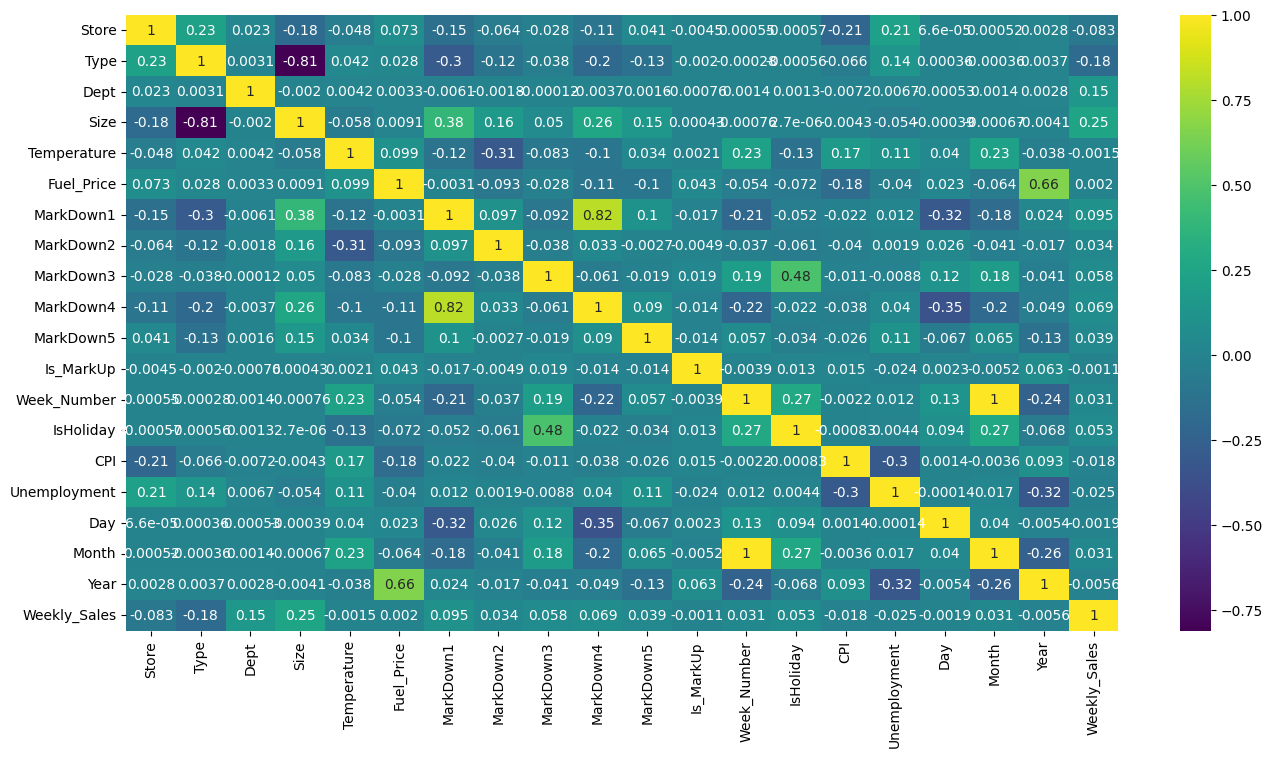

In [12]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(), annot=True, cmap = 'viridis')
plt.show()



# **Regression**

In [13]:
df

,Store,Type,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Is_MarkUp,Week_Number,IsHoliday,CPI,Unemployment,Day,Month,Year,Weekly_Sales
0,1,1,1,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106000,5,2,2010,24924.5000
1,1,1,2,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106000,5,2,2010,50605.2700
2,1,1,3,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106000,5,2,2010,13740.1200
3,1,1,4,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106000,5,2,2010,39954.0400
4,1,1,5,151315,42.31,2.572,21083.6181,3747.6985,228.8731,21775.2318,6685.9057,0,5,0,211.096358,8.106000,5,2,2010,32229.3800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536629,45,2,93,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,0,193.491386,8.590008,26,7,2013,3373.8589
536630,45,2,94,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,0,193.491386,8.590008,26,7,2013,4307.5731
536631,45,2,95,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,0,193.491386,8.590008,26,7,2013,56405.5206
536632,45,2,97,118221,76.06,3.804,212.0200,851.7300,2.0600,10.8800,1864.5700,0,30,0,193.491386,8.590008,26,7,2013,6375.3472


In [14]:
class regression:

    def __init__(self, x, y):
        # List of regression models to be evaluated
        self.models =[
                     ('RandomForestRegressor', RandomForestRegressor()),
                     ('DecisionTreeRegressor', DecisionTreeRegressor()),
                     ('XGBRegressor', XGBRegressor()),
                     ('LinearRegression', LinearRegression()),
                     ]
        # Split the data into training and testing sets
        self.x_train, self.x_test, self.y_train,self.y_test = train_test_split(x,y,test_size=0.2, random_state = 42)

    def all_model(self):
        # Train and evaluate each model
        print(self.x_train.shape, self.x_test.shape, self.y_train.shape, self.y_test.shape)
        result = []
        for model_name, model in self.models:
            model.fit(self.x_train, self.y_train)
            y_test_pred = model.predict(self.x_test)
            y_train_pred = model.predict(self.x_train)

            data ={'Model_Name': model_name,
                    'Train_Mean_Square_Error': round(mean_squared_error(self.y_train, y_train_pred),4),
                    'Test_Mean_Square_Error': round(mean_squared_error(self.y_test, y_test_pred),4),
                    'Train_Root_Mean_Square_Error': round(np.sqrt(mean_squared_error(self.y_train, y_train_pred)),2),
                    'Test_Root_Mean_Square_Error': round(np.sqrt(mean_squared_error(self.y_test, y_test_pred)),2),
                    'Train_Mean_Absolute_Error': round(mean_absolute_error(self.y_train, y_train_pred),4),
                    'Test_Mean_Absolute_Error': round(mean_absolute_error(self.y_test, y_test_pred),4),
                    'Train_R2_Score': round(r2_score(self.y_train, y_train_pred ),4),
                    'Test_R2_Score': round(r2_score(self.y_test, y_test_pred), 4)}
            result.append(data)

        self.model_score_df = pd.DataFrame(result)

        return self.model_score_df

In [15]:
# Defining Independent and dependent variable

y = df['Weekly_Sales']
x = df.drop('Weekly_Sales', axis =1)

In [16]:
# Initialize and train regression models, then evaluate their performance

regression_models = regression(x,y)
r_models = regression_models.all_model()
r_models

(429307, 19) (107327, 19) (429307,) (107327,)


,Model_Name,Train_Mean_Square_Error,Test_Mean_Square_Error,Train_Root_Mean_Square_Error,Test_Root_Mean_Square_Error,Train_Mean_Absolute_Error,Test_Mean_Absolute_Error,Train_R2_Score,Test_R2_Score
0,RandomForestRegressor,1.352775e+06,1.124199e+07,1163.09,3352.91,435.2366,1176.6480,0.9974,0.9786
1,DecisionTreeRegressor,0.000000e+00,2.272252e+07,0.00,4766.81,0.0000,1662.9959,1.0000,0.9568
2,XGBRegressor,2.389228e+07,2.751173e+07,4887.97,5245.16,2877.6008,2967.2277,0.9536,0.9477
3,LinearRegression,4.683207e+08,4.790833e+08,21640.72,21887.97,14554.7609,14631.5135,0.0908,0.0897


In [17]:
# Split the dataset into training and testing sets
regression_models = regression(x,y)
x_train, x_test, y_train, y_test = regression_models.x_train, regression_models.x_test, regression_models.y_train, regression_models.y_test
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((429307, 19), (107327, 19), (429307,), (107327,))

In [18]:
rf_model = RandomForestRegressor().fit(x_train, y_train)

y_test_pred = rf_model.predict(x_test)
y_train_pred = rf_model.predict(x_train)

data ={ 'Train_Mean_Square_Error': mean_squared_error(y_train, y_train_pred),
        'Test_Mean_Square_Error': mean_squared_error(y_test, y_test_pred),
        'Train_Root_Mean_Square_Error': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test_Root_Mean_Square_Error': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train_Mean_Absolute_Error': mean_absolute_error(y_train, y_train_pred),
        'Test_Mean_Absolute_Error': mean_absolute_error(y_test, y_test_pred),
        'Train_R2_Score': r2_score(y_train, y_train_pred ),
        'Test_R2_Score': r2_score(y_test, y_test_pred)}
data

{'Train_Mean_Square_Error': 1348168.992034039,
 'Test_Mean_Square_Error': 11186298.325090645,
 'Train_Root_Mean_Square_Error': 1161.1067961363585,
 'Test_Root_Mean_Square_Error': 3344.5924004414414,
 'Train_Mean_Absolute_Error': 435.5753156406069,
 'Test_Mean_Absolute_Error': 1177.1683003247458,
 'Train_R2_Score': 0.9973825502711761,
 'Test_R2_Score': 0.9787457430276193}

In [19]:
test_data = np.array([[18, 41, 95,120653, 36.33, 3.727, 1692.83, 1.5,7837.15, 579.46, 449.15, 0, 47.1, 3.0, 138.424, 8.243, 23.0, 11, 0.12]])
print('Predicted Weekly Sales Price: $', rf_model.predict(test_data)[0])

Predicted Weekly Sales Price: $ 44324.915376999976


In [11]:
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2']
}

# Create a RandomForestRegressor
rf_regressor = RandomForestRegressor()

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=rf_regressor, param_distributions=param_dist, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, n_iter=20)

# Fit the random search to the data
random_search.fit(x_train, y_train)

# Get the best parameters and the best model
best_params_random = random_search.best_params_
best_rf_model_random = random_search.best_estimator_

# Make predictions on the test set using the best model
predictions_random = best_rf_model_random.predict(x_test)

# Evaluate the model
mse_random = mean_squared_error(y_test, predictions_random)
print("Best Parameters (RandomizedSearchCV):", best_params_random)
print("Mean Squared Error on Test Set:", mse_random)

Best Parameters (RandomizedSearchCV): {'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 19, 'n_estimators': 127}
Mean Squared Error on Test Set: 142108352.1664071


In [12]:
random_search.best_estimator_

RandomForestRegressor(max_depth=40, max_features='log2', min_samples_split=19,
                      n_estimators=127)

In [14]:
rf_model1 = RandomForestRegressor(max_depth=40, max_features='log2', min_samples_split=19,
                                  n_estimators=127).fit(x_train, y_train)

y_test_pred = rf_model1.predict(x_test)
y_train_pred = rf_model1.predict(x_train)

data1 ={ 'Train_Mean_Square_Error': mean_squared_error(y_train, y_train_pred),
        'Test_Mean_Square_Error': mean_squared_error(y_test, y_test_pred),
        'Train_Root_Mean_Square_Error': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test_Root_Mean_Square_Error': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train_Mean_Absolute_Error': mean_absolute_error(y_train, y_train_pred),
        'Test_Mean_Absolute_Error': mean_absolute_error(y_test, y_test_pred),
        'Train_R2_Score': r2_score(y_train, y_train_pred ),
        'Test_R2_Score': r2_score(y_test, y_test_pred)}
data1

{'Train_Mean_Square_Error': 95620357.52053465,
 'Test_Mean_Square_Error': 136148368.3474039,
 'Train_Root_Mean_Square_Error': 9778.566230308748,
 'Test_Root_Mean_Square_Error': 11668.263296112404,
 'Train_Mean_Absolute_Error': 6076.479334458019,
 'Test_Mean_Absolute_Error': 7148.911382993213,
 'Train_R2_Score': 0.814649492061027,
 'Test_R2_Score': 0.7416946955754327}

In [16]:
print('RandomForestRegressor without Hyperparameter tuning')

print(data)

print('RandomForestRegressor with Hyperparameter tuning')

print(data1)

RandomForestRegressor without Hyperparameter tuning
{'Train_Mean_Square_Error': 1372354.5074656366, 'Test_Mean_Square_Error': 10911949.186838606, 'Train_Root_Mean_Square_Error': 1171.4753550398048, 'Test_Root_Mean_Square_Error': 3303.323960322179, 'Train_Mean_Absolute_Error': 437.08619981999743, 'Test_Mean_Absolute_Error': 1177.8610590819776, 'Train_R2_Score': 0.9973398279233952, 'Test_R2_Score': 0.979297479721684}
RandomForestRegressor with Hyperparameter tuning
{'Train_Mean_Square_Error': 95620357.52053465, 'Test_Mean_Square_Error': 136148368.3474039, 'Train_Root_Mean_Square_Error': 9778.566230308748, 'Test_Root_Mean_Square_Error': 11668.263296112404, 'Train_Mean_Absolute_Error': 6076.479334458019, 'Test_Mean_Absolute_Error': 7148.911382993213, 'Train_R2_Score': 0.814649492061027, 'Test_R2_Score': 0.7416946955754327}


**Conclusion:**
Based on the evaluation metrics, **the model without hyperparameter tuning performs better on the test set**. It generally has lower errors (MSE, RMSE, MAE) and a higher R2 score, suggesting better predictive performance.

In [11]:
test_data = np.array([[18, 41, 95,120653, 36.33, 3.727, 1692.83, 1.5,7837.15, 579.46, 449.15, 0, 47.1, 3.0, 138.424, 8.243, 23.0, 11, 0.12]])
print('Predicted Weekly Sales Price: $', rf_model.predict(test_data)[0])

Predicted Weekly Sales Price: $ 44367.52809999999
